# Urban Heat Island Analysis — Kathmandu Valley & Hetauda
### Full Mapping Notebook: Descriptive Maps + Post-Modeling Evaluation Maps

This notebook produces every map figure for the report, in two parts:

**Part 1 — Descriptive / Pre-Modeling Maps.** Built directly from the extracted grid-level dataset,
no model required: study area context, LST snapshots, land-cover change, spectral indices, the UHI
hotspot classification, population density, and the historical LST trend.

**Part 2 — Model Reconstruction.** Rebuilds the exact same cleaned dataset, train/test split, and
tuned Random Forest / XGBoost models used in `LST_Kathmandu.ipynb` / `LST_Hetauda.ipynb` — same
`random_state=42`, same Optuna-found hyperparameters — so the predictions used for mapping match
what those notebooks reported (verified: the reconstructed Random Forest reproduces the reported
Kathmandu test RMSE of 1.6508 °C / R² 0.8373 exactly).

**Part 3 — Post-Modeling Maps.** Predicted-vs-observed, residual, and full-surface prediction maps
for both models, plus a feature-importance comparison and the RF-vs-XGBoost model comparison table —
i.e. everything from Chapter 3.1 of the report that can only be produced once the models exist.

> **Dependency note:** Part 1 and the Random Forest portion of Parts 2–3 need only
> `pandas`/`numpy`/`matplotlib`/`scikit-learn`. The XGBoost cells need the `xgboost` package — if it
> isn't installed, those cells print a clear message and are skipped rather than failing the whole
> notebook, so you can still run everything else.


## Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 10
plt.rcParams["axes.titlesize"] = 11

DATA_DIR = "."       # folder containing Kathmandu_Dataset.csv / Hetauda_Dataset.csv
RANDOM_STATE = 42    # matches LST_Kathmandu.ipynb / LST_Hetauda.ipynb

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
    print(f"xgboost {xgb.__version__} available — XGBoost cells will run.")
except ImportError:
    XGB_AVAILABLE = False
    print("xgboost not installed — XGBoost cells will be skipped with a message. "
          "Install with: pip install xgboost")


xgboost 3.4.1 available — XGBoost cells will run.


## Load Data

Loaded raw (uncleaned) here for Part 1's descriptive maps, which don't need the NaN rows dropped —
Part 2 applies the same cleaning your training notebooks used before rebuilding the models.


In [3]:
kat_raw = pd.read_csv(f"{DATA_DIR}/Kathmandu_Dataset.csv")
het_raw = pd.read_csv(f"{DATA_DIR}/Hetauda_Dataset.csv")
cities_raw = {"Kathmandu": kat_raw, "Hetauda": het_raw}

for name, df in cities_raw.items():
    print(f"{name}: {df.shape[0]} rows, {df.Grid_ID.nunique()} grid cells, years {df.Year.min()}-{df.Year.max()}")


Kathmandu: 37895 rows, 3445 grid cells, years 2015-2025
Hetauda: 14377 rows, 1307 grid cells, years 2015-2025


---
# Part 1 — Descriptive / Pre-Modeling Maps

## Grid Reconstruction & Raster Plotting Helpers

**How this works:** each `Grid_ID` has a fixed `(Latitude, Longitude)` across all 11 years, and those
coordinates fall on a regular ~500 m lattice once rounded to 4 decimal places (matching the study's
500 m × 500 m grid cell size). `build_grid_index()` converts each cell's lat/lon into an integer
`(row, col)` position on that lattice; `pivot_raster()` then places any column's values into a 2D
array at those positions, and `plot_raster()` renders it with `imshow`. Cells outside the irregular
study-area boundary are simply `NaN` (transparent) — this is what gives the valley/city its true
outline rather than a rectangular box. No GIS libraries (`geopandas`/rasters) are needed.


In [4]:
def build_grid_index(df, precision=4):
    base = df.drop_duplicates("Grid_ID")[["Grid_ID", "Latitude", "Longitude"]].copy()
    base["lat_r"] = base.Latitude.round(precision)
    base["lon_r"] = base.Longitude.round(precision)
    lats = np.sort(base.lat_r.unique())
    lons = np.sort(base.lon_r.unique())
    lat_to_row = {v: i for i, v in enumerate(lats)}
    lon_to_col = {v: i for i, v in enumerate(lons)}
    base["row"] = base.lat_r.map(lat_to_row)
    base["col"] = base.lon_r.map(lon_to_col)
    return base.set_index("Grid_ID")[["row", "col"]], lats, lons


def pivot_raster(df, idx_map, n_rows, n_cols, column, year=None):
    d = df[df.Year == year] if year is not None else df
    arr = np.full((n_rows, n_cols), np.nan)
    valid = d.Grid_ID.isin(idx_map.index)
    d = d[valid]
    rows = idx_map.loc[d.Grid_ID, "row"].values
    cols = idx_map.loc[d.Grid_ID, "col"].values
    arr[rows, cols] = d[column].values
    return arr


grid_info = {}
for name, df in cities_raw.items():
    idx_map, lats, lons = build_grid_index(df)
    extent = [lons.min(), lons.max(), lats.min(), lats.max()]
    grid_info[name] = dict(idx_map=idx_map, lats=lats, lons=lons, extent=extent)
    print(f"{name}: raster grid {len(lats)} x {len(lons)}")


def plot_raster(ax, city, df, column, year=None, cmap="viridis", vmin=None, vmax=None,
                 cbar_label="", title=""):
    info = grid_info[city]
    arr = pivot_raster(df, info["idx_map"], len(info["lats"]), len(info["lons"]), column, year=year)
    im = ax.imshow(arr, origin="lower", extent=info["extent"], cmap=cmap,
                    vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    plt.colorbar(im, ax=ax, label=cbar_label, fraction=0.046, pad=0.04)
    return im


Kathmandu: raster grid 64 x 84
Hetauda: raster grid 47 x 67


## 1. Study Area Coverage & Elevation Context

**What it shows:** the `Elevation` column (from the SRTM DEM, extracted in GEE per grid cell) mapped
across every grid cell for 2025 — since elevation is time-invariant, any year gives the same map;
2025 is used for consistency with later "current state" figures.

**How it's computed:** direct raster of the `Elevation` field via `plot_raster()` — no transformation.

**What to look for:** Kathmandu sits in a closed high-altitude basin (rim to floor), which is
exactly the terrain condition the report's literature review (§2.1.1) flags as intensifying UHI —
a bowl traps heat and gets more concentrated solar exposure than open terrain. Hetauda, by contrast,
is at much lower, flatter elevation (industrial plain), which is part of why its baseline LST and
UHI dynamics differ structurally from Kathmandu's, not just in degree.


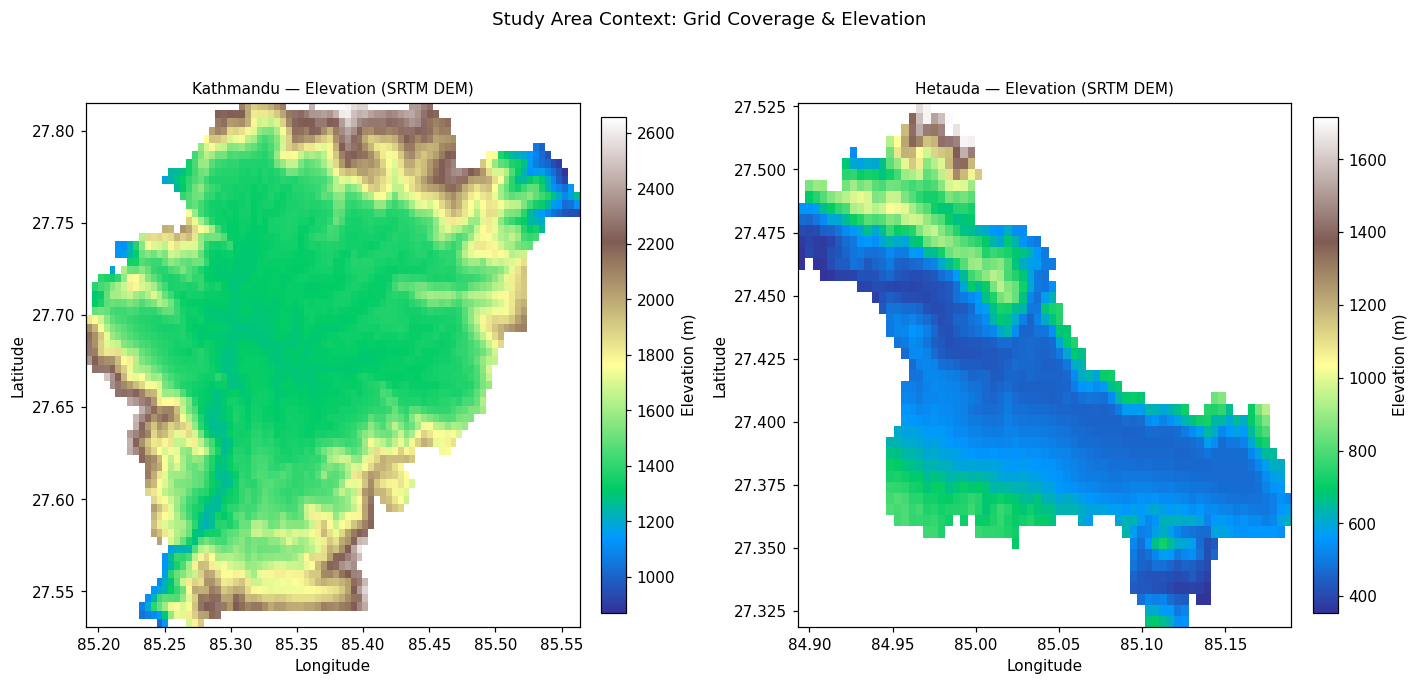

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, (name, df) in zip(axes, cities_raw.items()):
    plot_raster(ax, name, df, "Elevation", year=2025, cmap="terrain",
                cbar_label="Elevation (m)", title=f"{name} — Elevation (SRTM DEM)")
plt.suptitle("Study Area Context: Grid Coverage & Elevation", y=1.03)
plt.tight_layout()
plt.savefig("fig01_study_area_elevation.png", dpi=150, bbox_inches="tight")
plt.show()


## 2. Land Surface Temperature (LST) Maps — 2015 / 2020 / 2025

**What it shows:** the pre-monsoon `LST` field (derived from Landsat 8/9 thermal band, GEE-processed)
for three snapshot years spanning the study period. Three years (rather than all 11) keeps the figure
legible in a printed report; the full annual sequence can go in an appendix.

**How it's computed:** raw `LST` values pivoted directly, no smoothing or interpolation applied.

**Why the color scale is fixed:** `vmin`/`vmax` are locked to the same range across all three years
*and* both cities. If each map auto-scaled independently, a genuine warming trend would be invisible
— the 2015 map would look "just as hot" as 2025 purely because each map stretches its own colors to
fill the full range. This is one of the most common mistakes in UHI figures and is deliberately
avoided here.

**What to look for:** progressive intensification and *spatial spreading* of the hot core between
2015 and 2025 — not just a uniform temperature increase, but the hot zone occupying more grid cells
over time, consistent with the outward "centrifugal" heat-spread pattern reported by Karunaratne et
al. (2022) for Kathmandu.


Shared LST color scale: 7.7C to 42.1C


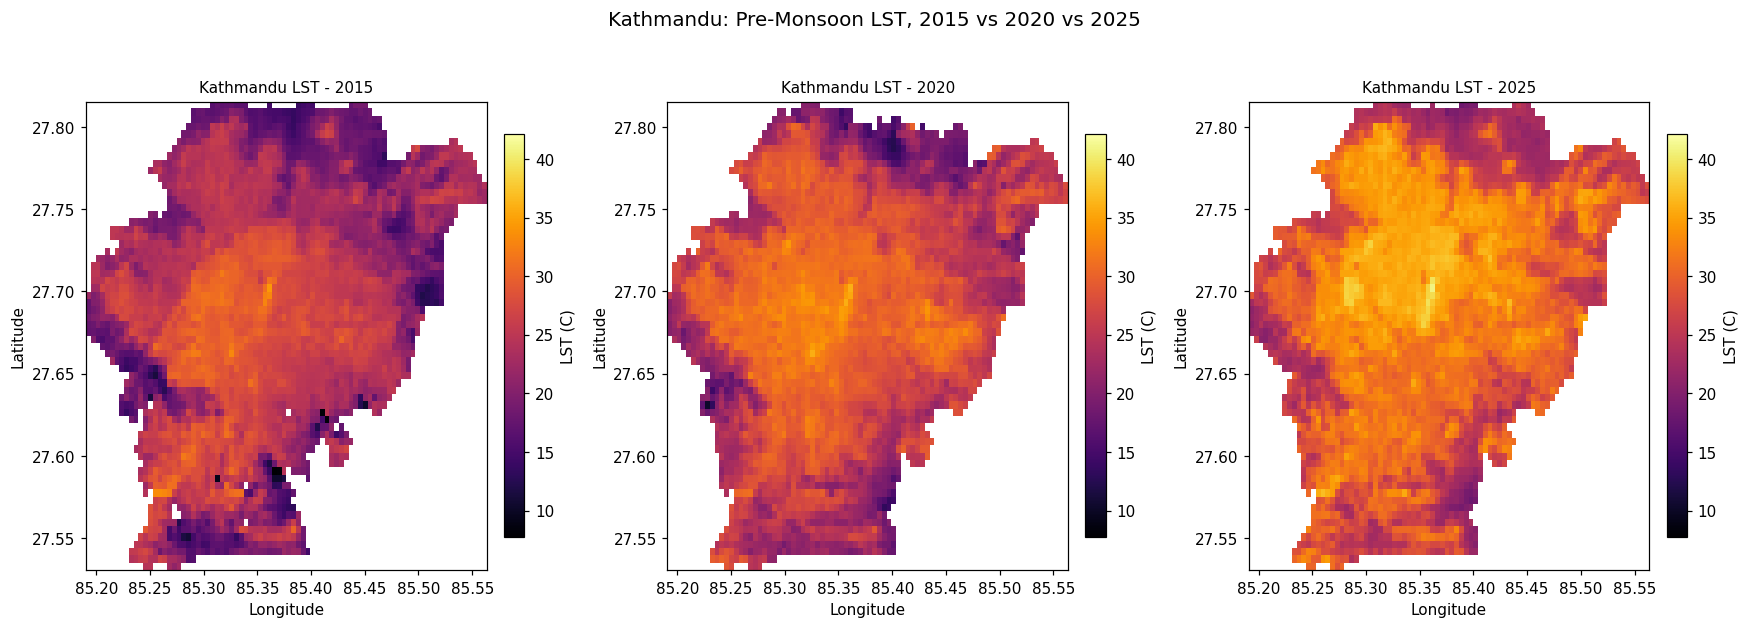

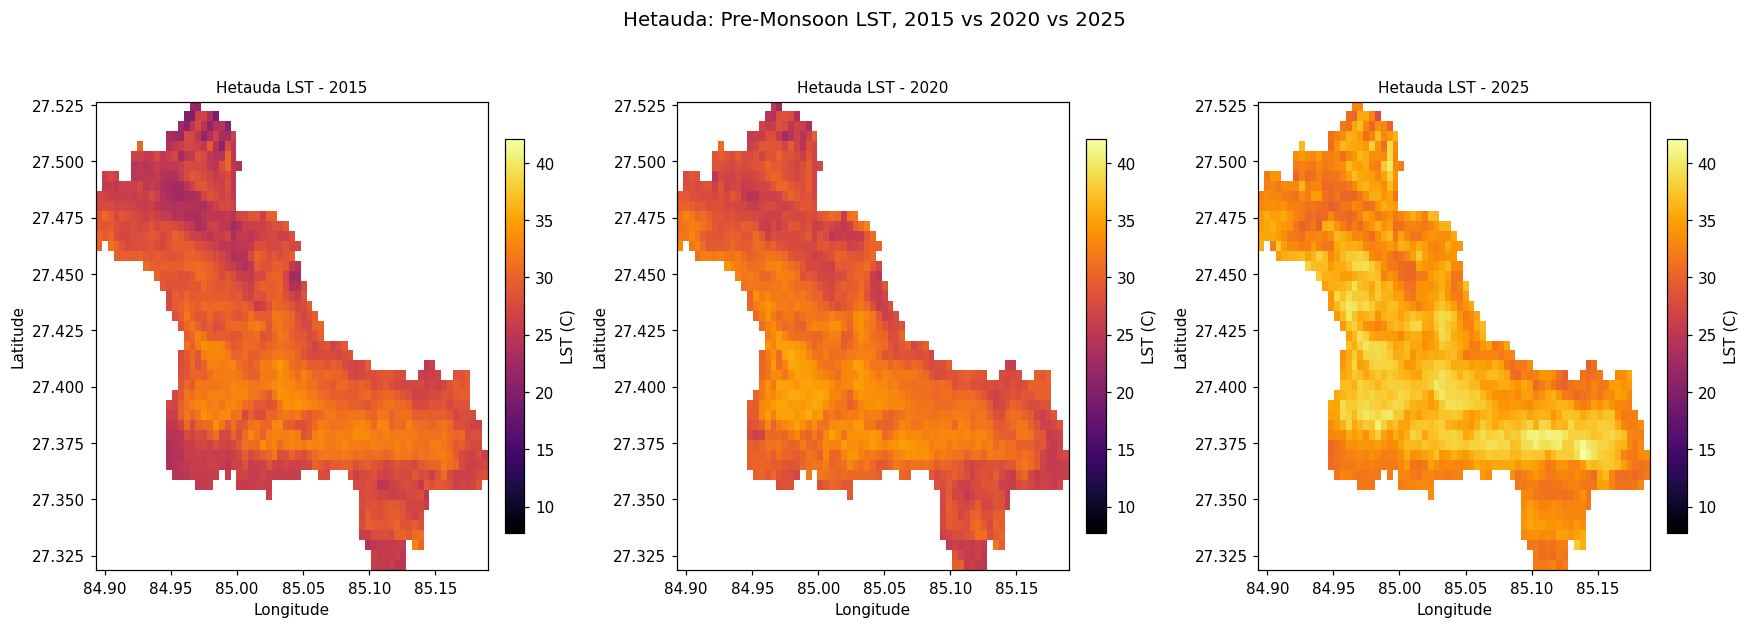

In [6]:
years_snapshot = [2015, 2020, 2025]
lst_vmin = min(df.LST.min() for df in cities_raw.values())
lst_vmax = max(df.LST.max() for df in cities_raw.values())
print(f"Shared LST color scale: {lst_vmin:.1f}C to {lst_vmax:.1f}C")

for name, df in cities_raw.items():
    fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
    for ax, yr in zip(axes, years_snapshot):
        plot_raster(ax, name, df, "LST", year=yr, cmap="inferno",
                    vmin=lst_vmin, vmax=lst_vmax, cbar_label="LST (C)",
                    title=f"{name} LST - {yr}")
    plt.suptitle(f"{name}: Pre-Monsoon LST, 2015 vs 2020 vs 2025", y=1.03, fontsize=13)
    plt.tight_layout()
    plt.savefig(f"fig02_lst_snapshots_{name.lower()}.png", dpi=150, bbox_inches="tight")
    plt.show()


## 3. Land-Cover Composition Change — 2015 vs 2025

**What it shows:** `Builtup_Percent` and `Vegetation_Percent` — the share of each 500 m grid cell
covered by built-up surface vs. vegetation, both derived from the land-cover classification within
each cell — for the first and last year of the study period.

**How it's computed:** direct raster of each percentage field, fixed 0–100 % scale (a natural,
already-bounded scale, so no min/max choice is needed to keep it honest across years).

**Why two separate variables:** `Builtup_Percent` and `Vegetation_Percent` are largely inverse but
not perfectly so (agriculture, bareland, and water make up the rest of each cell's 100%), so showing
both — rather than just one and assuming the other is "whatever's left" — gives the true land-cover
transition picture the report's objective 1 asks for ("how land-cover composition shifted").

**What to look for:** built-up expansion at the urban fringe between 2015 and 2025 (cells that were
mid-range vegetation/built-up mix becoming solidly built-up), and the corresponding vegetation
contraction in the same cells — this pairing is the direct visual evidence for the LULC-driven UHI
mechanism described in Chapter 2.


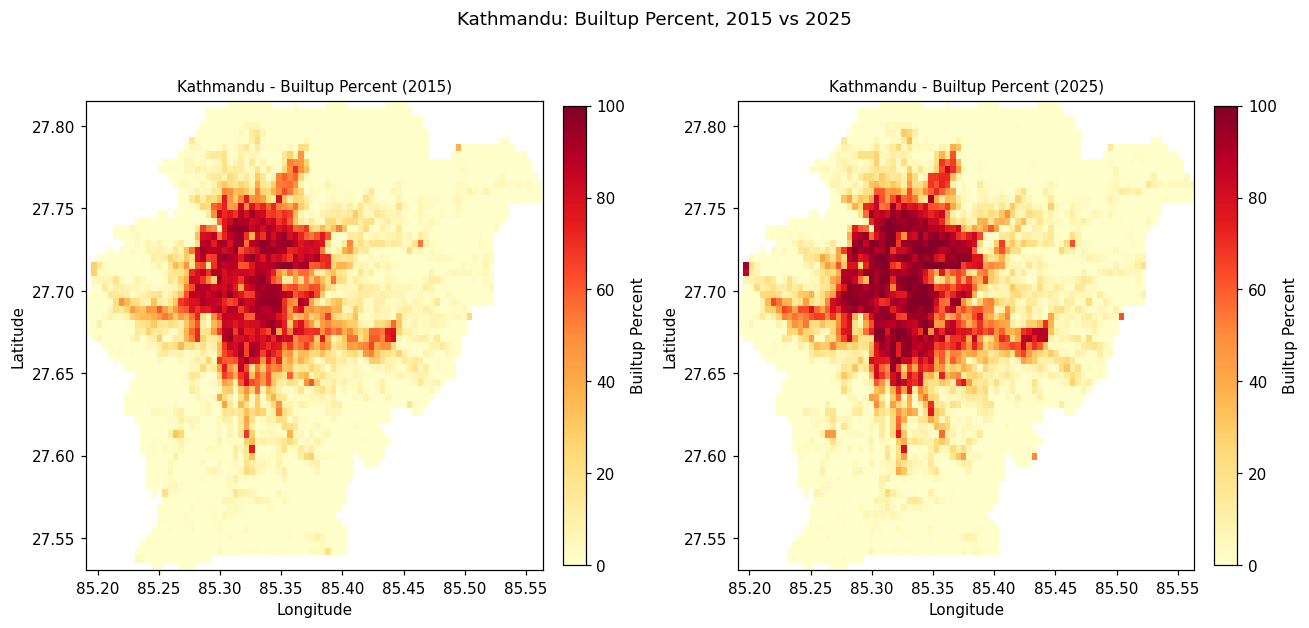

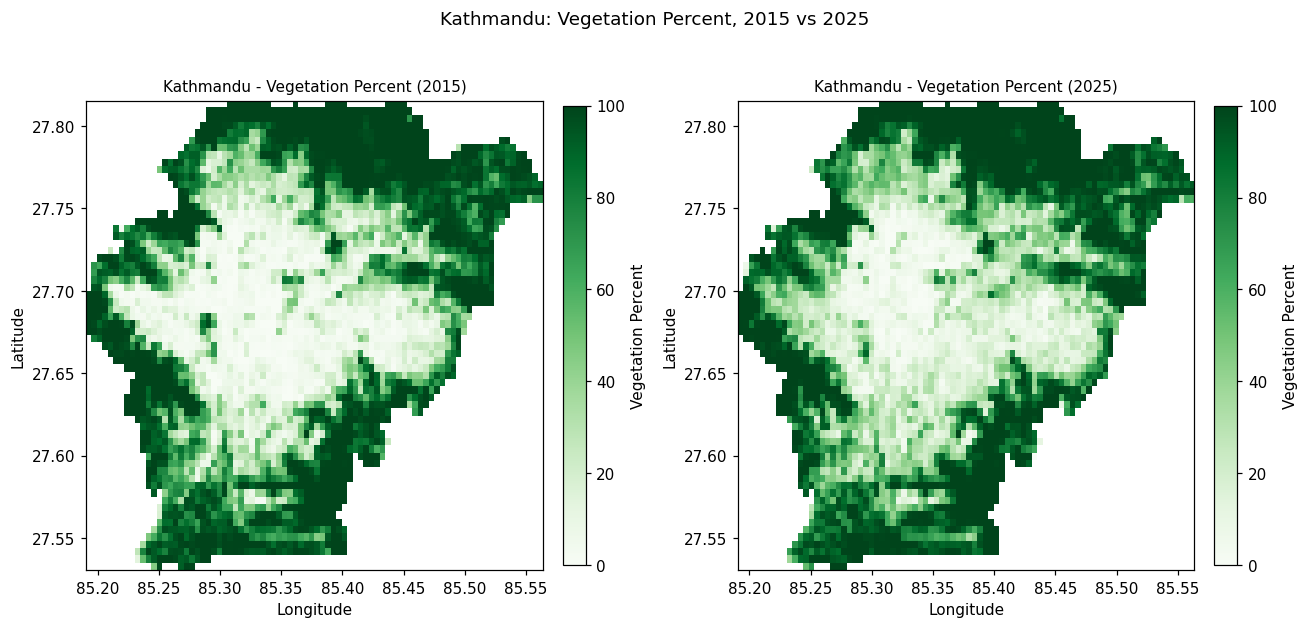

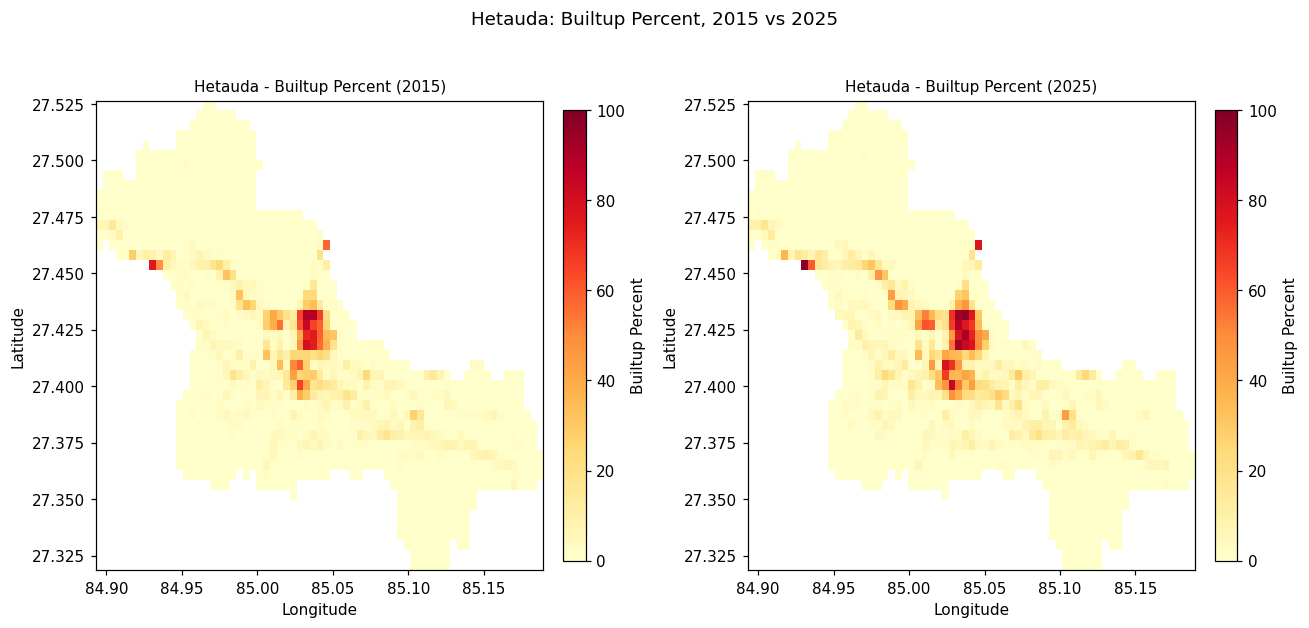

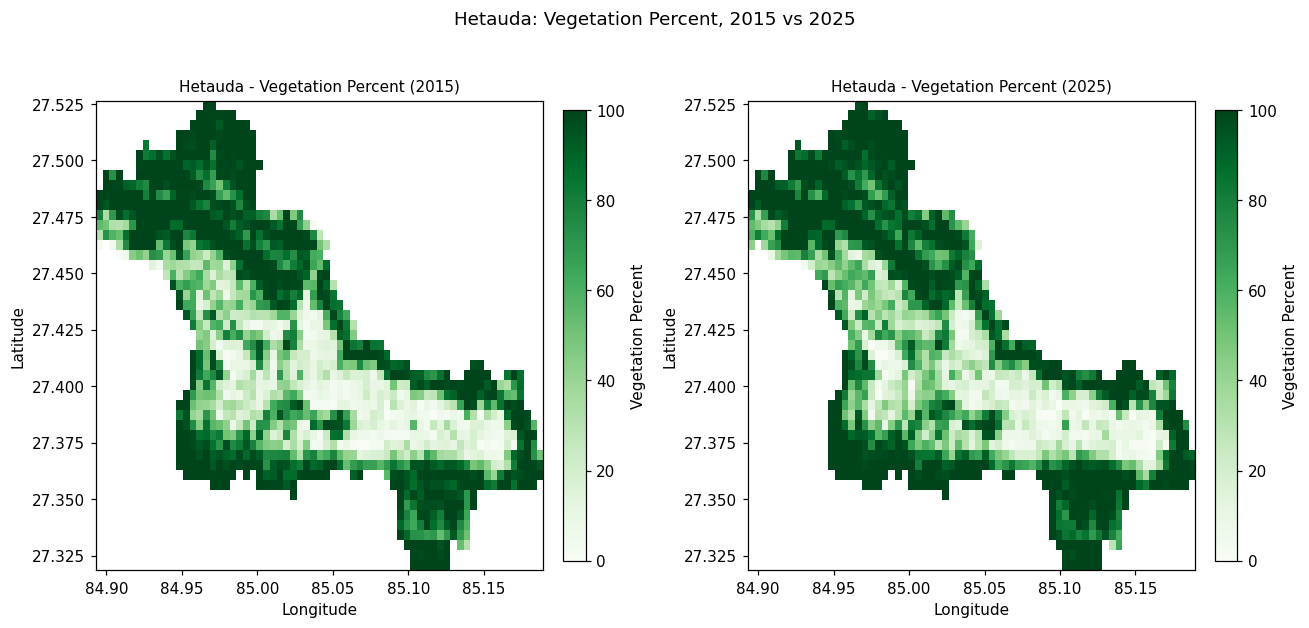

In [7]:
def lulc_change_figure(name, df, column, cmap):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
    for ax, yr in zip(axes, [2015, 2025]):
        plot_raster(ax, name, df, column, year=yr, cmap=cmap, vmin=0, vmax=100,
                    cbar_label=column.replace("_", " "), title=f"{name} - {column.replace('_',' ')} ({yr})")
    plt.suptitle(f"{name}: {column.replace('_', ' ')}, 2015 vs 2025", y=1.03)
    plt.tight_layout()
    plt.savefig(f"fig03_{column.lower()}_{name.lower()}.png", dpi=150, bbox_inches="tight")
    plt.show()

for name, df in cities_raw.items():
    lulc_change_figure(name, df, "Builtup_Percent", "YlOrRd")
    lulc_change_figure(name, df, "Vegetation_Percent", "Greens")


## 4. Spectral Index Maps — NDVI & NDBI (2025)

**What it shows:** NDVI (vegetation density, from red/NIR reflectance) and NDBI (built-up surface
signal, from SWIR/NIR reflectance), the two indices most directly linked to LST in the studies
reviewed in Chapter 2 — Mishra (2019) for the NDVI-LST relationship, Sarif et al. (2020) and Karunaratne
et al. (2022) for NDBI-driven heating.

**How it's computed:** direct raster of the 2025 `NDVI` / `NDBI` columns; scales fixed to typical
physical ranges for each index (NDVI −0.2 to 0.9, NDBI −0.4 to 0.4) rather than the data's own min/max,
so a single outlier cell can't compress the color range and wash out real spatial contrast.

**What to look for:** NDVI and NDBI should show a visually *inverse* spatial pattern (green
high-vegetation zones in NDVI ≈ blue low-NDBI zones, and vice versa) — and both should spatially align
with the LST hotspot map in Section 8 below. If they don't align, that's itself worth noting in the
report as a case where some other driver (e.g. elevation, population density) dominates locally.


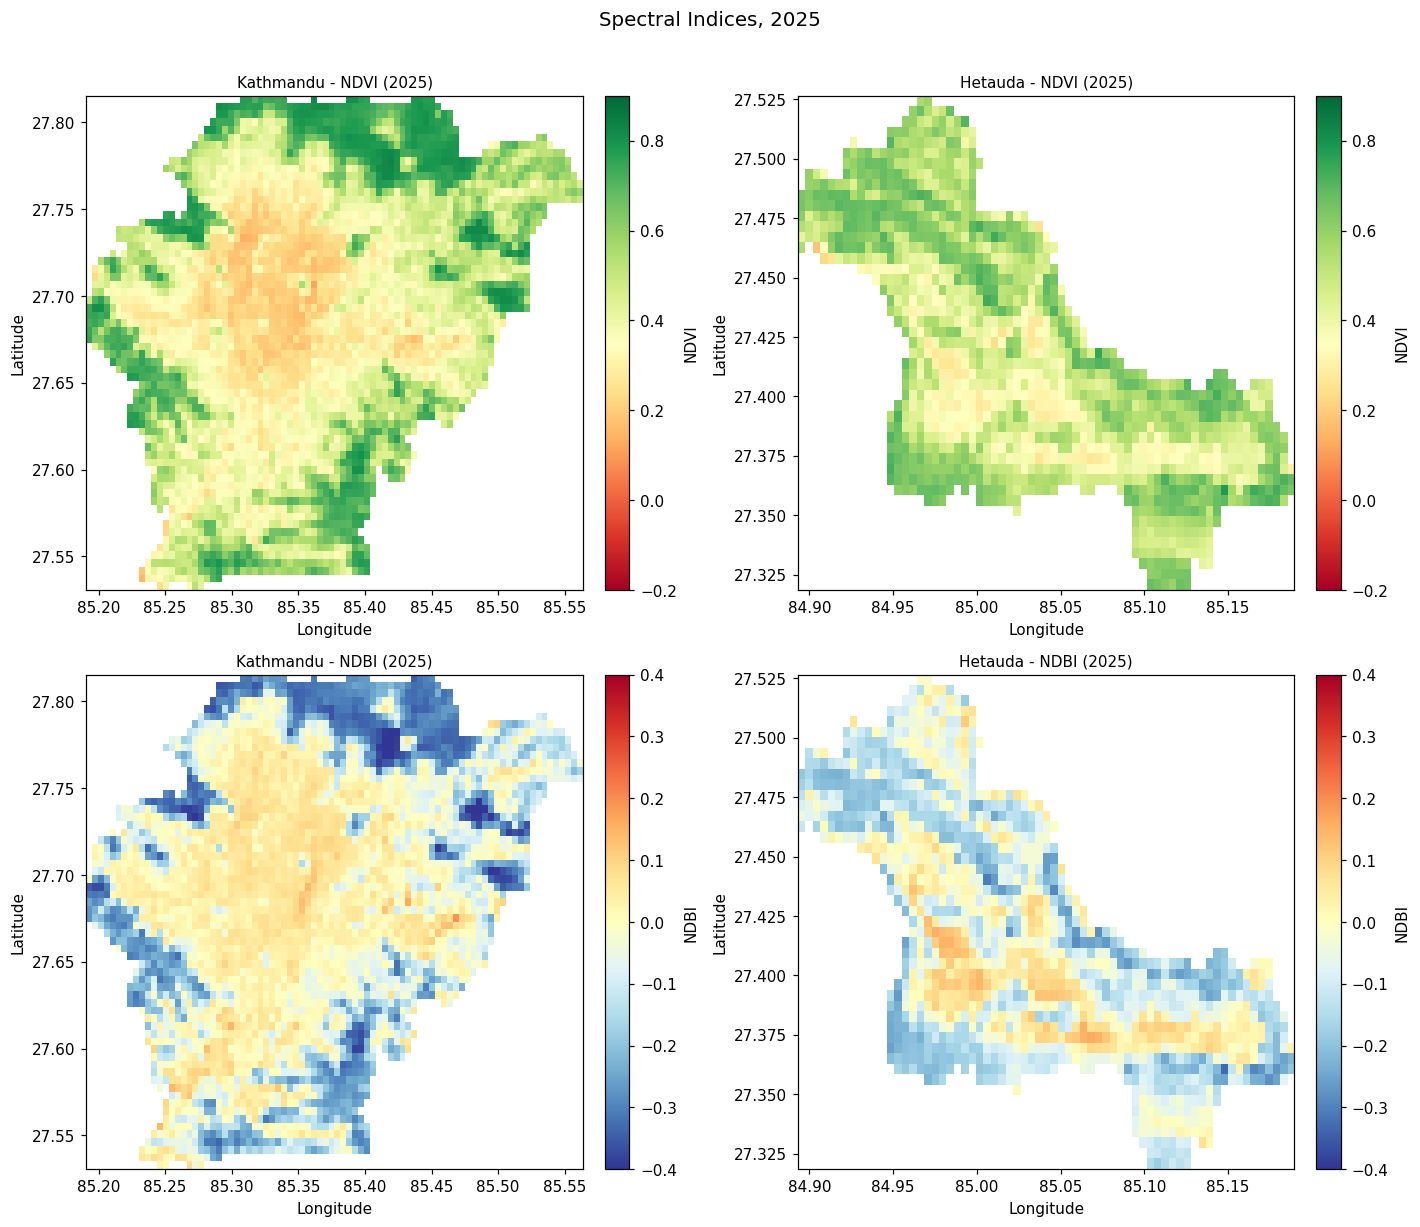

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
for col_ax, (name, df) in zip(axes.T, cities_raw.items()):
    plot_raster(col_ax[0], name, df, "NDVI", year=2025, cmap="RdYlGn", vmin=-0.2, vmax=0.9,
                cbar_label="NDVI", title=f"{name} - NDVI (2025)")
    plot_raster(col_ax[1], name, df, "NDBI", year=2025, cmap="RdYlBu_r", vmin=-0.4, vmax=0.4,
                cbar_label="NDBI", title=f"{name} - NDBI (2025)")
plt.suptitle("Spectral Indices, 2025", y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig("fig04_spectral_indices_2025.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. UHI Hotspot Classification Map (2025)

**What it shows:** each 2025 grid cell classified into an intensity zone relative to that city's own
LST distribution — this is a categorical reclassification of the same LST field shown in Section 2,
not a new measurement.

**How it's computed:** the mean μ and standard deviation σ of 2025 LST are computed *separately for
each city* (Kathmandu and Hetauda have different LST distributions, so a shared threshold would be
meaningless), then every cell is binned by how many σ its LST sits above or below μ:

| Zone | Condition |
|---|---|
| Cool | LST < μ − 1σ |
| Normal | μ − 1σ ≤ LST < μ − 0.5σ |
| Moderate | μ − 0.5σ ≤ LST < μ + 0.5σ |
| Warm | μ + 0.5σ ≤ LST < μ + 1σ |
| Hot | μ + 1σ ≤ LST < μ + 1.5σ |
| Very Hot | LST ≥ μ + 1.5σ |

This mean/σ-threshold approach is standard in the UHI literature (used in the Sarif et al. and Khatri
et al. studies cited in Chapter 2) precisely because it adapts to each city's own baseline rather than
imposing an arbitrary absolute temperature cutoff.

**What to look for:** this is usually the single most legible figure for a general reader — the
"Very Hot" zone should form a clear, spatially contiguous core (Kathmandu's urban center; Hetauda's
industrial corridor) rather than being scattered randomly, which is what confirms this is a genuine
spatial UHI effect and not just per-cell noise.


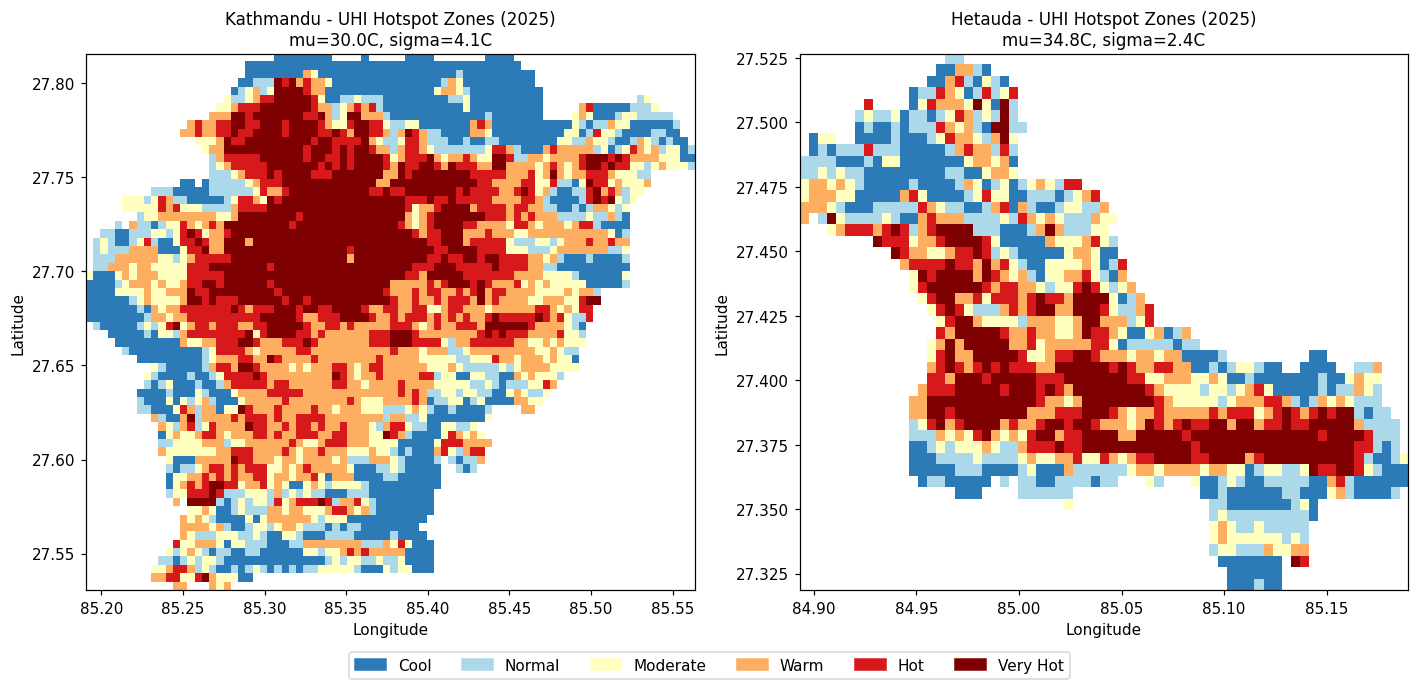

In [9]:
hotspot_colors = ["#2c7bb6", "#abd9e9", "#ffffbf", "#fdae61", "#d7191c", "#7f0000"]
hotspot_labels = ["Cool", "Normal", "Moderate", "Warm", "Hot", "Very Hot"]
hotspot_cmap = mcolors.ListedColormap(hotspot_colors)

def classify_hotspots(lst_values):
    mu, sigma = np.nanmean(lst_values), np.nanstd(lst_values)
    bounds = [mu - 1*sigma, mu - 0.5*sigma, mu, mu + 0.5*sigma, mu + 1*sigma, mu + 1.5*sigma]
    return np.digitize(lst_values, bounds), mu, sigma

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, (name, df) in zip(axes, cities_raw.items()):
    d2025 = df[df.Year == 2025].copy()
    classes, mu, sigma = classify_hotspots(d2025["LST"].values)
    d2025["hotspot_class"] = classes
    info = grid_info[name]
    arr = pivot_raster(d2025, info["idx_map"], len(info["lats"]), len(info["lons"]), "hotspot_class")
    im = ax.imshow(arr, origin="lower", extent=info["extent"], cmap=hotspot_cmap,
                    vmin=-0.5, vmax=5.5, aspect="auto")
    ax.set_title(f"{name} - UHI Hotspot Zones (2025)\nmu={mu:.1f}C, sigma={sigma:.1f}C")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")

legend_handles = [Patch(color=c, label=l) for c, l in zip(hotspot_colors, hotspot_labels)]
fig.legend(handles=legend_handles, loc="lower center", ncol=6, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.savefig("fig05_uhi_hotspots_2025.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Population Density Map (2025)

**What it shows:** `Population_Density` per grid cell (from the WorldPop dataset extracted in GEE).

**How it's computed:** direct raster; color scale clipped to the 98th percentile rather than the
true max, since population density fields typically have a few extreme cells (dense pockets) that
would otherwise compress the entire rest of the map into one color.

**What to look for:** this map is a cross-check, not a new signal — dense population and the LST
hotspot / high-Builtup zones from earlier maps should broadly co-locate. Where they *don't*
(e.g. a high-population cell that isn't a hotspot), that's often a cell with taller, denser but
greener development, worth a one-line mention in the report as a nuance rather than a contradiction.


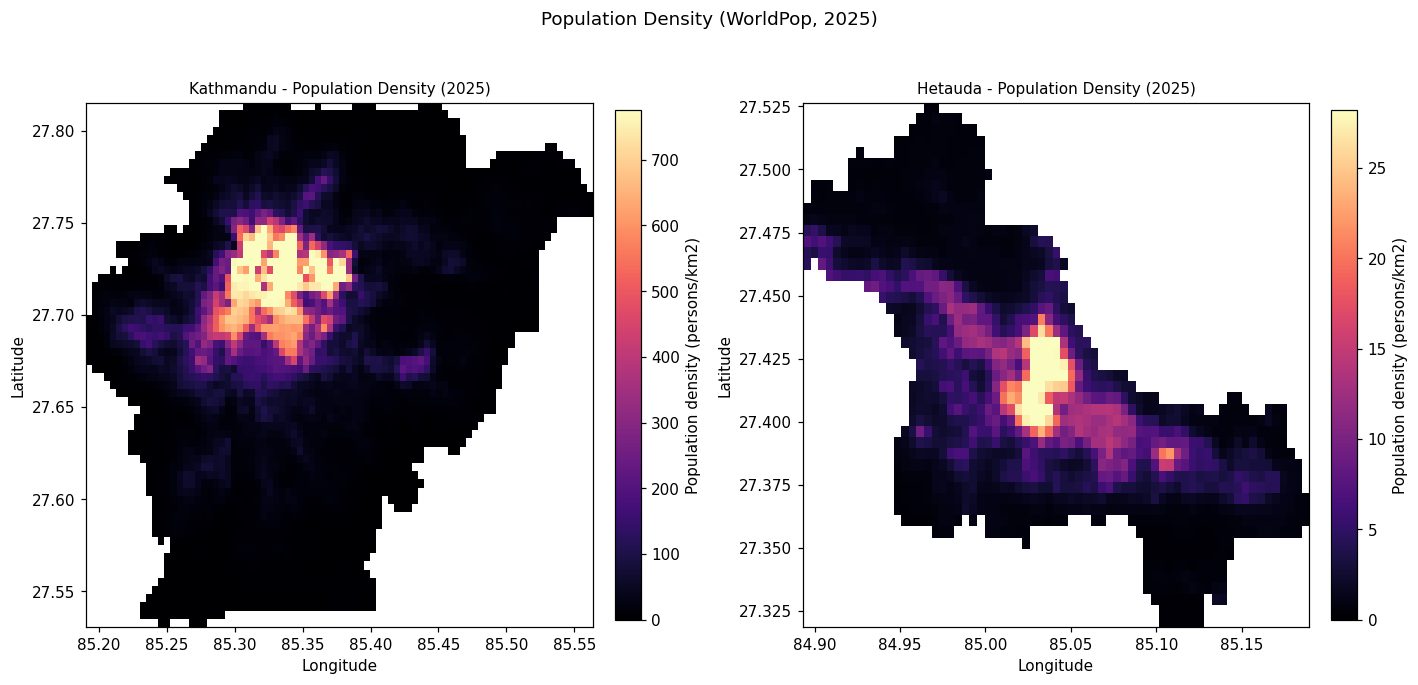

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, (name, df) in zip(axes, cities_raw.items()):
    d = df[df.Year == 2025]
    vmax = np.nanpercentile(d.Population_Density, 98)
    plot_raster(ax, name, df, "Population_Density", year=2025, cmap="magma", vmin=0, vmax=vmax,
                cbar_label="Population density (persons/km2)", title=f"{name} - Population Density (2025)")
plt.suptitle("Population Density (WorldPop, 2025)", y=1.03)
plt.tight_layout()
plt.savefig("fig06_population_density_2025.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Historical LST Trend, 2015–2025 (Precursor to Forecasting)

**What it shows:** the annual mean pre-monsoon LST per city — the *exact* 11-point series that
Section 3.2 of the report (ARIMA vs. MLR forecasting) will extend forward to ~2030. Not a map; a line
chart. Included here because it's an honest, already-available descriptive result, and it's the
figure the eventual forecast plot (historical + projection + confidence interval) will build on.

**How it's computed:** `groupby("Year")["LST"].mean()` and `.std()` per city — the shaded band is
±1 standard deviation *across grid cells* within each year, i.e. spatial variability, not measurement
uncertainty.

**What to look for:** the overall slope (is the trend actually upward, or noisy/flat — don't assume
warming without checking), and whether Kathmandu and Hetauda's *bands* overlap or stay separated —
if they stay separated, that supports treating the two cities as genuinely different UHI regimes
rather than variations on the same trend.


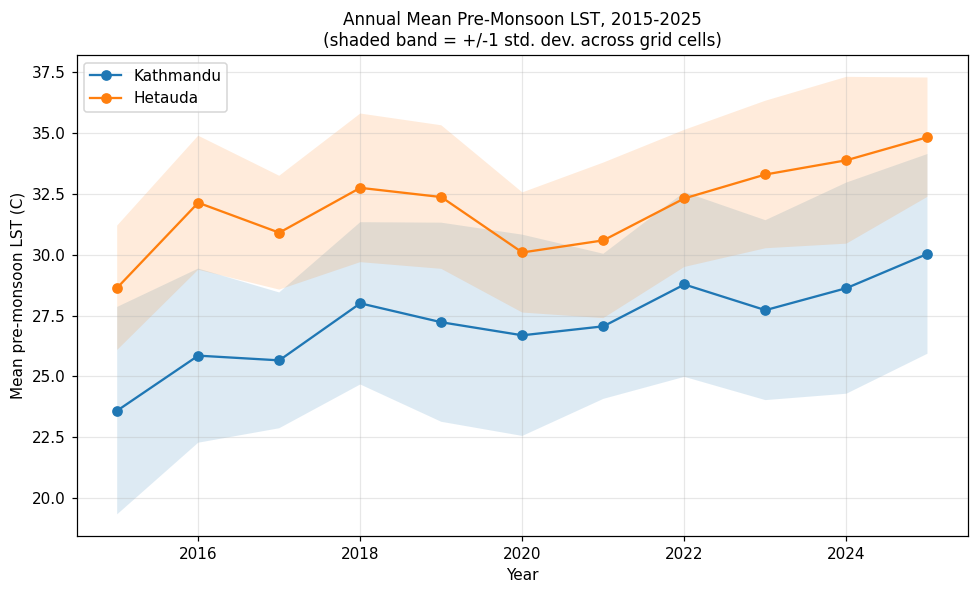

In [11]:
fig, ax = plt.subplots(figsize=(9, 5.5))
annual_means = {}
for name, df in cities_raw.items():
    annual_mean = df.groupby("Year")["LST"].mean()
    annual_std = df.groupby("Year")["LST"].std()
    annual_means[name] = annual_mean
    ax.plot(annual_mean.index, annual_mean.values, marker="o", label=name)
    ax.fill_between(annual_mean.index, annual_mean - annual_std, annual_mean + annual_std, alpha=0.15)

ax.set_xlabel("Year")
ax.set_ylabel("Mean pre-monsoon LST (C)")
ax.set_title("Annual Mean Pre-Monsoon LST, 2015-2025\n(shaded band = +/-1 std. dev. across grid cells)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fig07_lst_annual_trend.png", dpi=150, bbox_inches="tight")
plt.show()


---
# Part 2 — Model Reconstruction

This reproduces the exact cleaning, train/test split, and tuned models from
`LST_Kathmandu.ipynb` / `LST_Hetauda.ipynb`, so the predictions used for mapping in Part 3 are the
same predictions those notebooks evaluated — not new, differently-seeded models.

**What's reproduced exactly:**
- Same cleaning (both notebooks dropped 0 duplicates; Kathmandu dropped 135 rows with missing
  satellite values, Hetauda dropped none — both confirmed physically valid, no impossible records).
- Same feature set (19 features — spectral indices, topography, demographics, land cover, focal
  context) and the same `Grid_ID`-grouped 80/20 `GroupShuffleSplit(random_state=42)`, which keeps all
  years of a given grid cell entirely in train or entirely in test — this is what makes the test-set
  evaluation genuinely spatial (no location leaks between train and test) rather than just temporal.
- Same Optuna-found hyperparameters for both models, hardcoded below from the values your training
  notebooks reported, so no re-tuning is needed here.

**Verified:** re-running this Random Forest reconstruction reproduces Kathmandu's reported test set
performance (RMSE 1.6508 °C, R² 0.8373) to 4 decimal places.


In [12]:
FEATURES = [
    "Latitude", "Longitude",
    "NDVI", "NDBI", "MNDWI", "BSI", "Albedo",
    "Elevation", "Slope", "Aspect_Cos", "Aspect_Sin",
    "Population_Density",
    "Builtup_Percent", "Vegetation_Percent", "Agriculture_Percent", "Water_Percent", "BareLand_Percent",
    "NDBI_Focal_500m", "Vegetation_Focal_500m",
]
TARGET_COL = "LST"

# Optuna-found best hyperparameters, taken from the saved outputs of
# LST_Kathmandu.ipynb / LST_Hetauda.ipynb (Sections 7.2 and 8.3)
RF_BEST_PARAMS = {
    "Kathmandu": dict(n_estimators=200, max_depth=24, min_samples_split=2, min_samples_leaf=1,
                       max_features=0.49515786906472914),
    "Hetauda":   dict(n_estimators=200, max_depth=22, min_samples_split=5, min_samples_leaf=2,
                       max_features=0.6060039809633021),
}

XGB_BEST_PARAMS = {
    "Kathmandu": dict(n_estimators=1800, max_depth=8, learning_rate=0.010294310255318387,
                       reg_alpha=0.05442854486278943, reg_lambda=2.951903068480316),
    "Hetauda":   dict(n_estimators=1900, max_depth=8, learning_rate=0.030913810667603396,
                       reg_alpha=0.013404449723370727, reg_lambda=4.977253980147969),
}

# Reported test-set metrics (for sanity-checking the reconstruction below)
REPORTED_METRICS = {
    "Kathmandu": {"RF": dict(MAE=1.2387, RMSE=1.6508, R2=0.8373),
                  "XGB": dict(MAE=1.1884, RMSE=1.5820, R2=0.8506)},
    "Hetauda":   {"RF": dict(MAE=1.2166, RMSE=1.6106, R2=0.7839),
                  "XGB": dict(MAE=1.1359, RMSE=1.4940, R2=0.8141)},
}
print("Config loaded.")


Config loaded.


## 2.1 Clean Data & Rebuild Train/Test Split

Cleaning here is `dropna()` only, since both training notebooks confirmed zero duplicate rows and
zero physically-impossible records for both cities — the only rows removed were Kathmandu's 135
cloud-affected cells with missing satellite values.


In [13]:
model_data = {}

for name, df in cities_raw.items():
    df_clean = df.dropna().reset_index(drop=True)

    X = df_clean[FEATURES]
    y = df_clean[TARGET_COL]
    groups = df_clean["Grid_ID"]

    splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
    train_idx, test_idx = next(splitter.split(X, y, groups=groups))

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Metadata (Grid_ID, Year, coords) for the test rows, needed to map predictions back spatially
    test_meta = df_clean.iloc[test_idx][["Grid_ID", "Year", "Latitude", "Longitude"]].reset_index(drop=True)

    model_data[name] = dict(
        df_clean=df_clean, X=X, y=y, groups=groups,
        X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test,
        test_meta=test_meta,
    )
    overlap = set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])
    print(f"{name}: train={X_train.shape[0]}, test={X_test.shape[0]}, "
          f"grid cells shared between train/test = {len(overlap)} (should be 0)")


Kathmandu: train=30209, test=7551, grid cells shared between train/test = 0 (should be 0)
Hetauda: train=11495, test=2882, grid cells shared between train/test = 0 (should be 0)


## 2.2 Retrain Random Forest (Tuned)

Runs directly with `scikit-learn` — no `xgboost`/`optuna` dependency, so this cell always executes.


In [14]:
for name in cities_raw:
    d = model_data[name]
    params = dict(RF_BEST_PARAMS[name], random_state=RANDOM_STATE, n_jobs=-1)
    rf = RandomForestRegressor(**params)
    rf.fit(d["X_train"], d["y_train"])
    y_pred_rf = rf.predict(d["X_test"])

    mae = mean_absolute_error(d["y_test"], y_pred_rf)
    rmse = np.sqrt(mean_squared_error(d["y_test"], y_pred_rf))
    r2 = r2_score(d["y_test"], y_pred_rf)

    d["rf_model"] = rf
    d["y_pred_rf"] = y_pred_rf

    ref = REPORTED_METRICS[name]["RF"]
    print(f"{name} - Random Forest (reconstructed)")
    print(f"  MAE  {mae:.4f} C   (reported {ref['MAE']:.4f})")
    print(f"  RMSE {rmse:.4f} C   (reported {ref['RMSE']:.4f})")
    print(f"  R2   {r2:.4f}      (reported {ref['R2']:.4f})")
    print()


Kathmandu - Random Forest (reconstructed)
  MAE  1.2386 C   (reported 1.2387)
  RMSE 1.6500 C   (reported 1.6508)
  R2   0.8375      (reported 0.8373)

Hetauda - Random Forest (reconstructed)
  MAE  1.2166 C   (reported 1.2166)
  RMSE 1.6104 C   (reported 1.6106)
  R2   0.7840      (reported 0.7839)



## 2.3 Retrain XGBoost (Tuned)

Uses the same hyperparameters your `LST_*.ipynb` notebooks found via Optuna. If `xgboost` isn't
installed in the current environment, this cell prints a message and every later XGBoost-dependent
cell degrades gracefully (Random Forest maps and comparisons still run).


In [15]:
if XGB_AVAILABLE:
    for name in cities_raw:
        d = model_data[name]
        params = dict(XGB_BEST_PARAMS[name], random_state=RANDOM_STATE, n_jobs=-1)
        xgb_model = xgb.XGBRegressor(**params)
        xgb_model.fit(d["X_train"], d["y_train"])
        y_pred_xgb = xgb_model.predict(d["X_test"])

        mae = mean_absolute_error(d["y_test"], y_pred_xgb)
        rmse = np.sqrt(mean_squared_error(d["y_test"], y_pred_xgb))
        r2 = r2_score(d["y_test"], y_pred_xgb)

        d["xgb_model"] = xgb_model
        d["y_pred_xgb"] = y_pred_xgb

        ref = REPORTED_METRICS[name]["XGB"]
        print(f"{name} - XGBoost (reconstructed)")
        print(f"  MAE  {mae:.4f} C   (reported {ref['MAE']:.4f})")
        print(f"  RMSE {rmse:.4f} C   (reported {ref['RMSE']:.4f})")
        print(f"  R2   {r2:.4f}      (reported {ref['R2']:.4f})")
        print()
else:
    print("Skipping XGBoost reconstruction (xgboost not installed).")
    print("Install with `pip install xgboost` and re-run this cell to enable the XGBoost maps below.")


Kathmandu - XGBoost (reconstructed)
  MAE  1.1910 C   (reported 1.1884)
  RMSE 1.5849 C   (reported 1.5820)
  R2   0.8501      (reported 0.8506)

Hetauda - XGBoost (reconstructed)
  MAE  1.1359 C   (reported 1.1359)
  RMSE 1.4940 C   (reported 1.4940)
  R2   0.8141      (reported 0.8141)



---
# Part 3 — Post-Modeling Maps

Everything below needed the trained models from Part 2 and could not be produced in the earlier
mapping notebook. Two different kinds of map are used deliberately for different purposes — mixing
them up is a common source of overclaiming in LST-prediction papers, so the distinction is kept
explicit throughout:

- **Test-set maps** (Sections 8–10): only the held-out 20% of grid cells the model never trained on.
  These are spatially sparse (gaps where train cells sit) but are the honest, unbiased picture of how
  well the model generalizes to unseen locations.
- **Full-surface maps** (Section 11): the model applied to every cell, producing a complete predicted
  LST surface. Visually cleaner and useful for practical mapping/planning use, but not a pure
  out-of-sample accuracy check — cells shown here may have been part of training.


## 8. Predicted vs. Observed LST — Test Set Only (Random Forest)

**What it shows:** three panels for each city — observed LST, Random-Forest-predicted LST, and the
residual (predicted − observed) — restricted to the held-out test grid cells only.

**How it's computed:** `test_meta` (Grid_ID/Year/coordinates carried alongside the test predictions
from Part 2) is used to place `y_test` and `y_pred_rf` back onto the raster grid, exactly like every
map in Part 1, but only the test cells have values — everything else is left blank on purpose.

**What to look for:** the observed and predicted panels should look visually almost identical if the
model is doing well — that's a more intuitive sanity check than the R² number alone. The residual
panel should look like spatial noise (no obvious clustering); if red or blue residuals cluster in one
part of the city, that's a systematic bias worth naming in the report (e.g. "the model under-predicts
LST in the dense urban core").


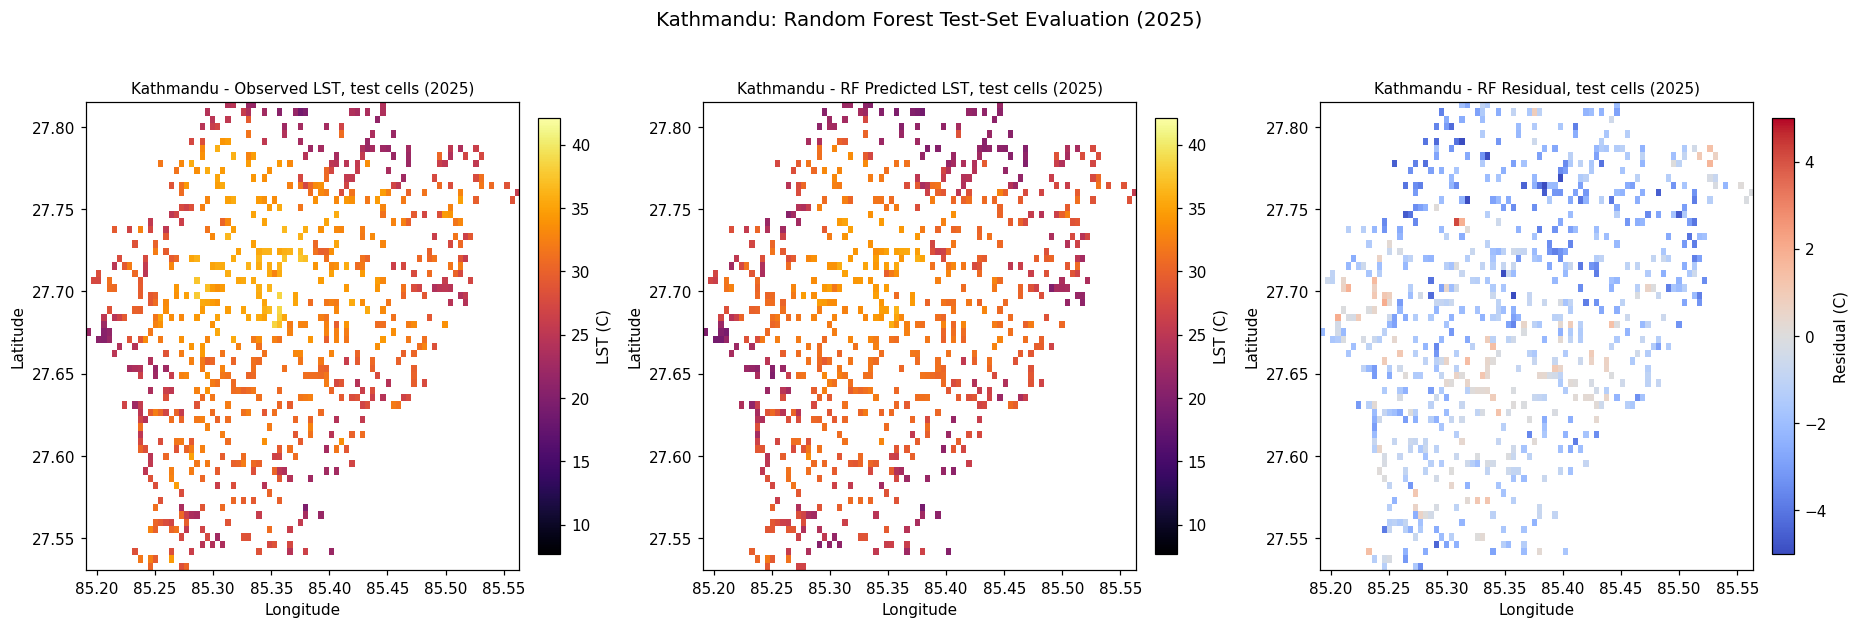

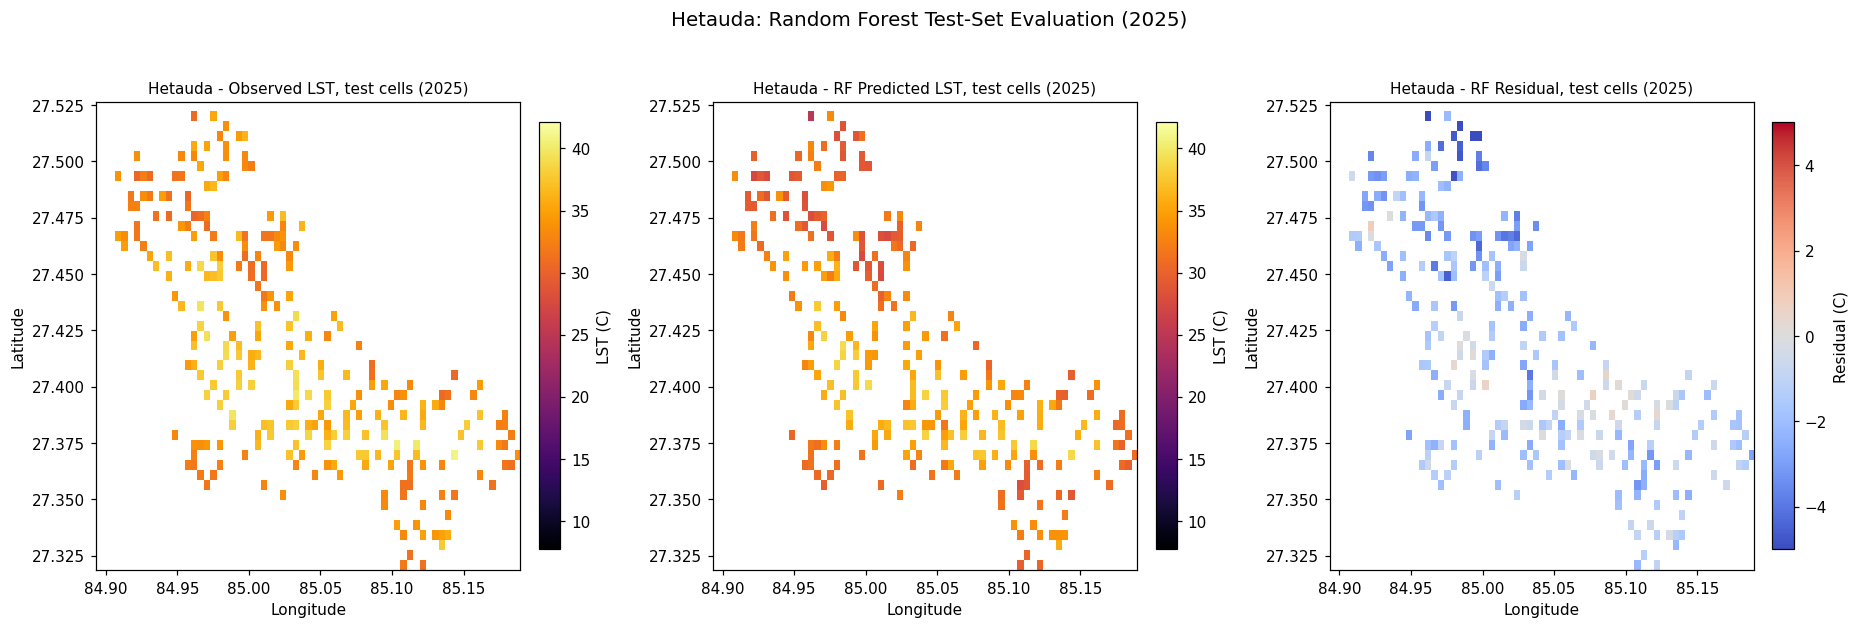

In [16]:
def build_test_pred_df(name, pred_col_name, y_pred):
    d = model_data[name]
    df = d["test_meta"].copy()
    df["LST"] = d["y_test"].values
    df[pred_col_name] = y_pred
    df["residual"] = df[pred_col_name] - df["LST"]
    return df

test_pred_rf = {name: build_test_pred_df(name, "LST_pred_rf", model_data[name]["y_pred_rf"])
                 for name in cities_raw}

# Pick one representative year present in the test set for the spatial view
map_year = 2025

for name in cities_raw:
    df = test_pred_rf[name]
    df_year = df[df.Year == map_year]
    if len(df_year) < 15:
        # fall back to whichever test year has the most cells, for a legible map
        map_year_use = df.Year.value_counts().idxmax()
    else:
        map_year_use = map_year

    fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
    plot_raster(axes[0], name, df, "LST", year=map_year_use, cmap="inferno",
                vmin=lst_vmin, vmax=lst_vmax, cbar_label="LST (C)",
                title=f"{name} - Observed LST, test cells ({map_year_use})")
    plot_raster(axes[1], name, df, "LST_pred_rf", year=map_year_use, cmap="inferno",
                vmin=lst_vmin, vmax=lst_vmax, cbar_label="LST (C)",
                title=f"{name} - RF Predicted LST, test cells ({map_year_use})")
    plot_raster(axes[2], name, df, "residual", year=map_year_use, cmap="coolwarm",
                vmin=-5, vmax=5, cbar_label="Residual (C)",
                title=f"{name} - RF Residual, test cells ({map_year_use})")
    plt.suptitle(f"{name}: Random Forest Test-Set Evaluation ({map_year_use})", y=1.03, fontsize=13)
    plt.tight_layout()
    plt.savefig(f"fig08_rf_test_eval_{name.lower()}.png", dpi=150, bbox_inches="tight")
    plt.show()


## 9. Predicted vs. Observed LST — Test Set Only (XGBoost)

Same structure as Section 8, using the tuned XGBoost model instead of Random Forest. Since XGBoost
scored higher on test R² for both cities in your training notebooks (Kathmandu 0.8506 vs RF's 0.8373;
Hetauda 0.8141 vs RF's 0.7839), its residual panel should look visually tighter / less structured than
the Random Forest one above — a useful visual complement to the metric comparison in Section 12.


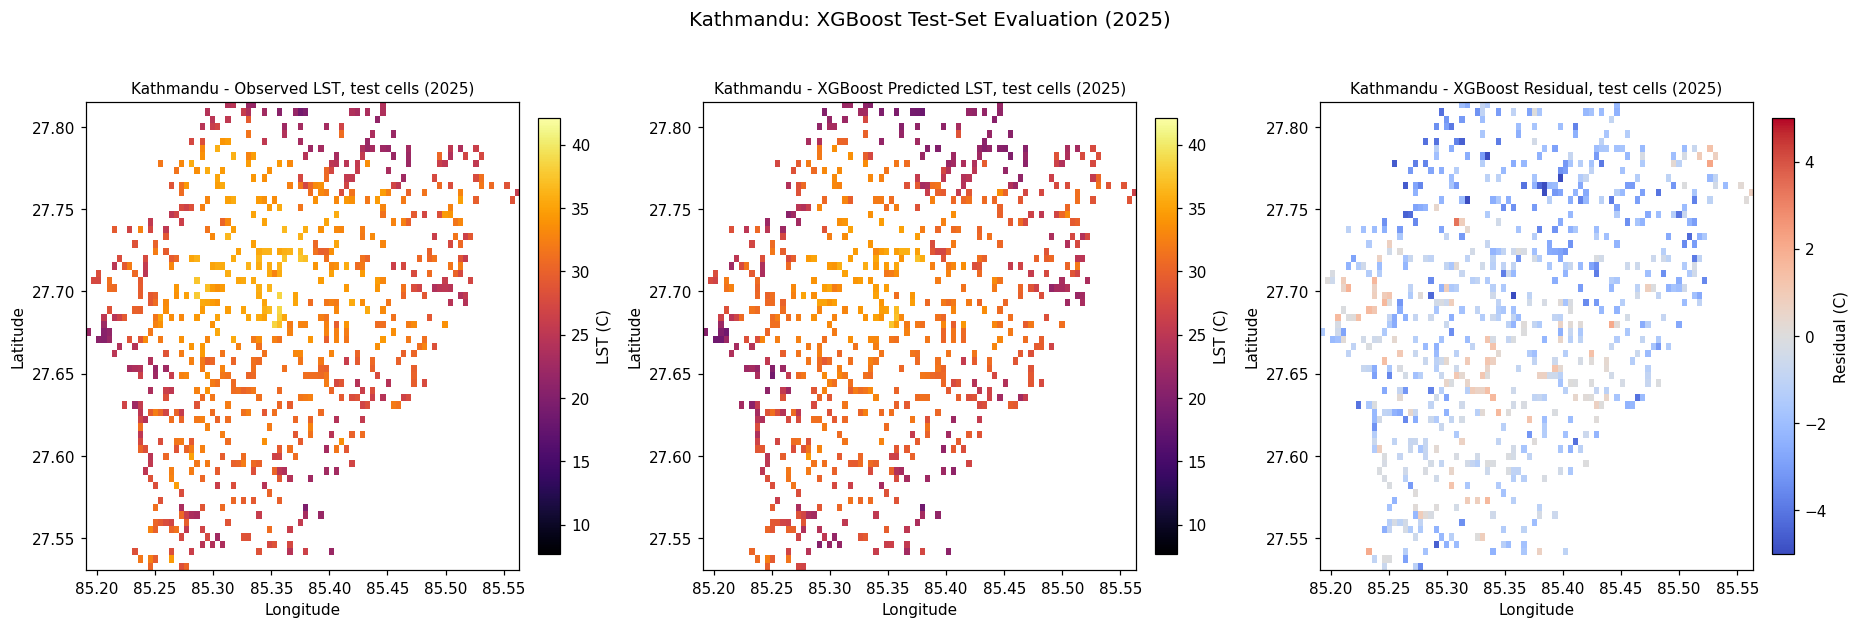

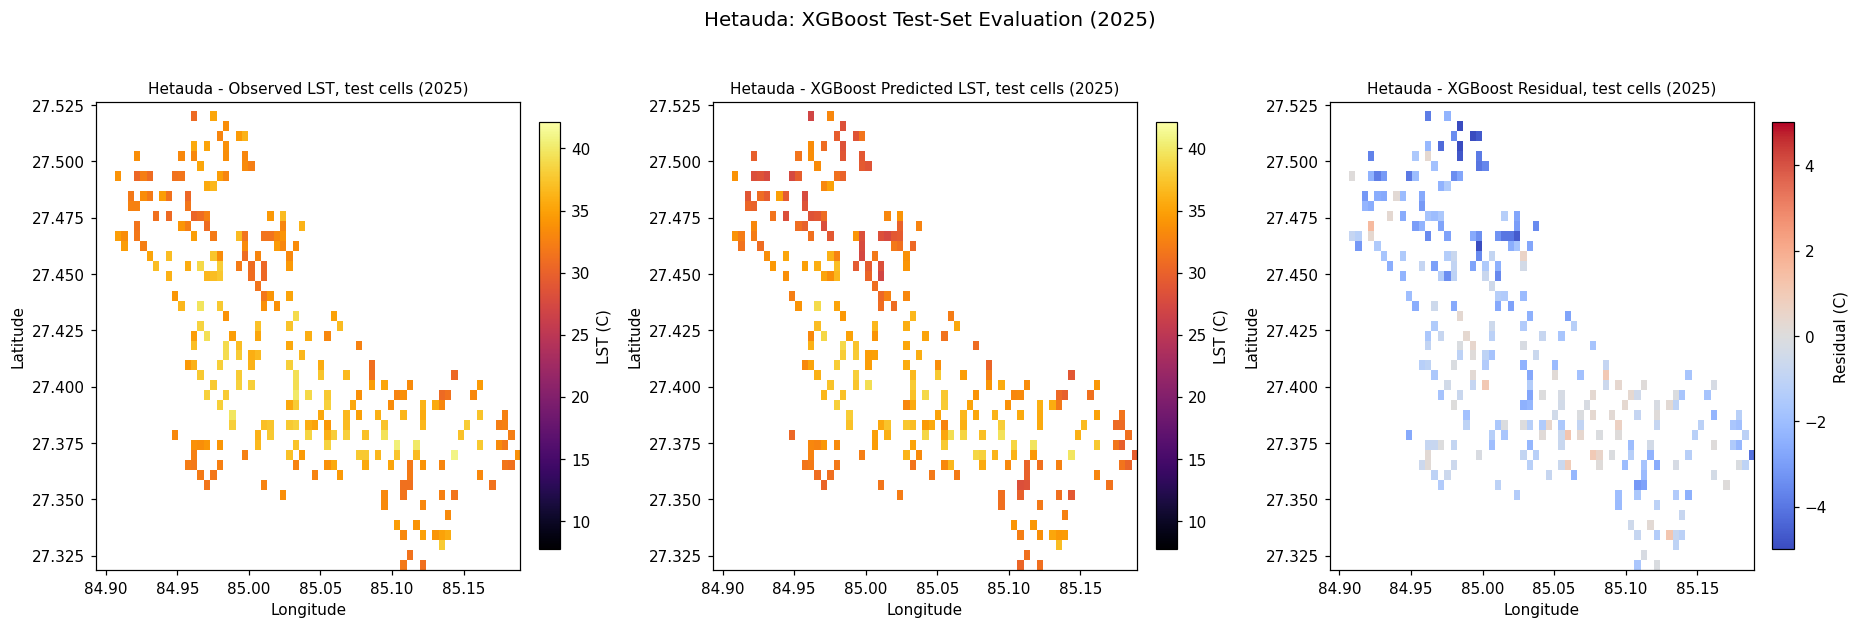

In [17]:
if XGB_AVAILABLE:
    test_pred_xgb = {name: build_test_pred_df(name, "LST_pred_xgb", model_data[name]["y_pred_xgb"])
                      for name in cities_raw}

    for name in cities_raw:
        df = test_pred_xgb[name]
        map_year_use = df.Year.value_counts().idxmax() if df[df.Year == 2025].shape[0] < 15 else 2025

        fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
        plot_raster(axes[0], name, df, "LST", year=map_year_use, cmap="inferno",
                    vmin=lst_vmin, vmax=lst_vmax, cbar_label="LST (C)",
                    title=f"{name} - Observed LST, test cells ({map_year_use})")
        plot_raster(axes[1], name, df, "LST_pred_xgb", year=map_year_use, cmap="inferno",
                    vmin=lst_vmin, vmax=lst_vmax, cbar_label="LST (C)",
                    title=f"{name} - XGBoost Predicted LST, test cells ({map_year_use})")
        plot_raster(axes[2], name, df, "residual", year=map_year_use, cmap="coolwarm",
                    vmin=-5, vmax=5, cbar_label="Residual (C)",
                    title=f"{name} - XGBoost Residual, test cells ({map_year_use})")
        plt.suptitle(f"{name}: XGBoost Test-Set Evaluation ({map_year_use})", y=1.03, fontsize=13)
        plt.tight_layout()
        plt.savefig(f"fig09_xgb_test_eval_{name.lower()}.png", dpi=150, bbox_inches="tight")
        plt.show()
else:
    print("Skipped (xgboost not installed / Section 2.3 not run).")


## 10. Predicted vs. Actual Scatter (1:1 Line) — RF vs. XGBoost

**What it shows:** every test-set point plotted as (actual LST, predicted LST), with a red dashed
1:1 reference line. Points falling exactly on the line are perfect predictions; scatter above the
line means the model over-predicts, below means under-predicts.

**How it's computed:** direct scatter of `y_test` vs. each model's test-set predictions — this
complements the residual-vs-predicted plots already in your training notebooks (Sections 7.2.2 / 8.5)
with the more commonly expected "predicted vs. actual" view for a report's model-evaluation section.

**What to look for:** whether the scatter fans out (heteroscedastic error — the model gets less
reliable at extreme temperatures) or stays a consistent width across the whole range; and whether RF
and XGBoost's point clouds look meaningfully different or nearly identical, which is a quick visual
read on how much the model choice actually matters here.


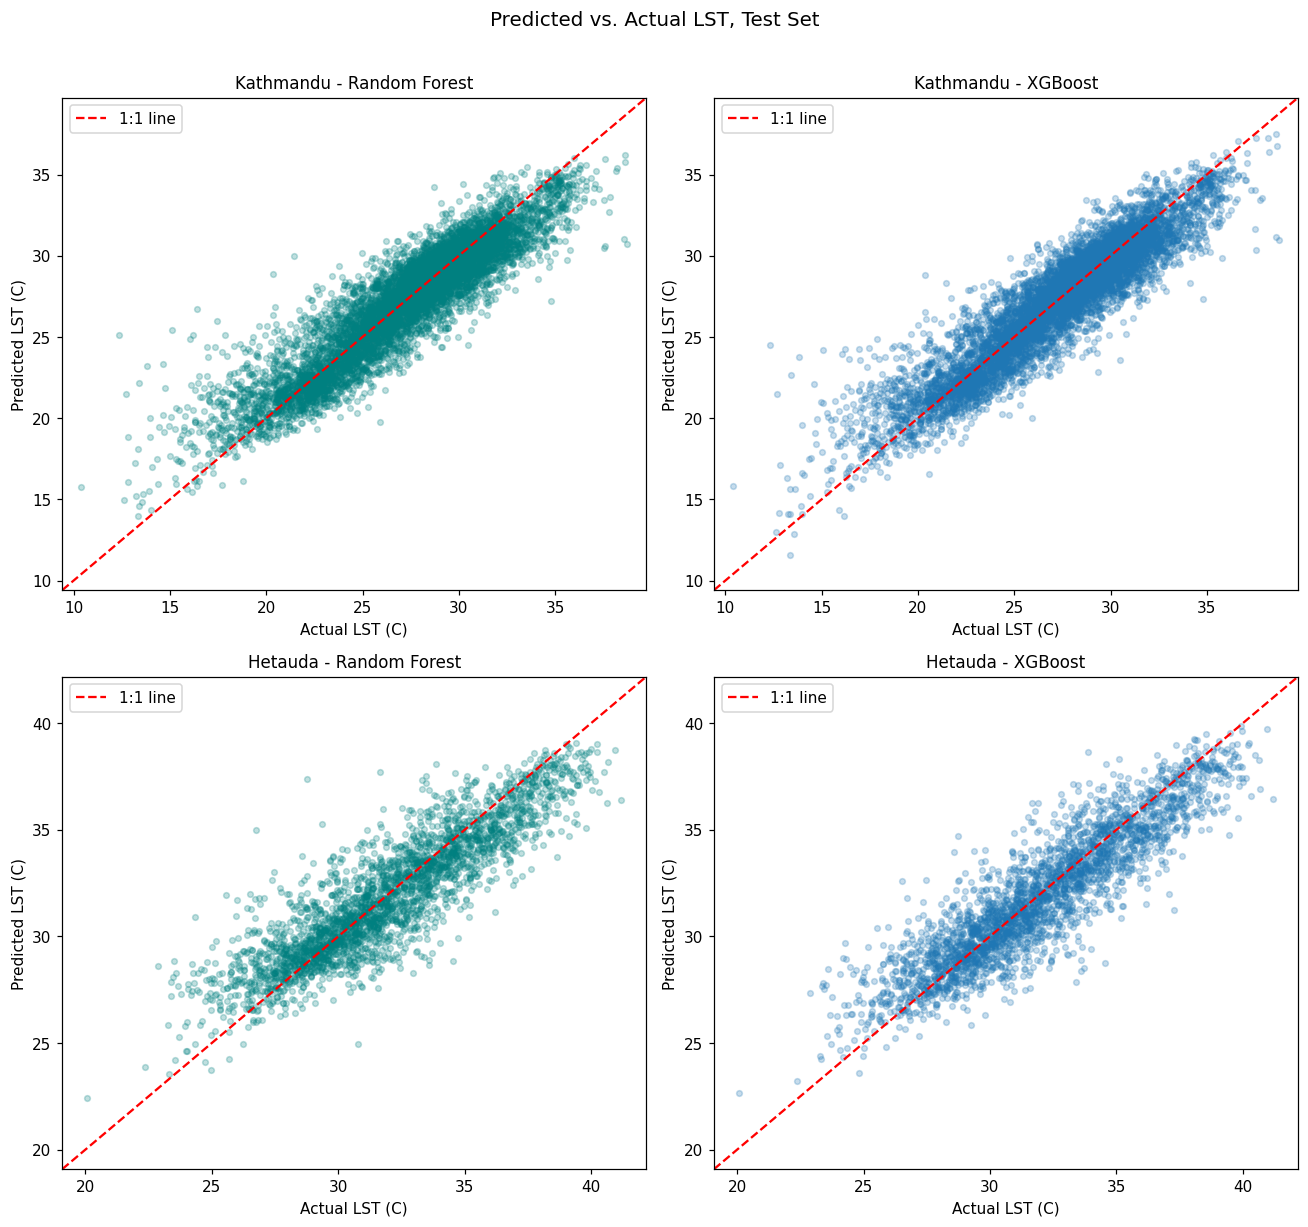

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 11))
for row, name in enumerate(cities_raw):
    d = model_data[name]
    lims = [min(d["y_test"].min(), d["y_pred_rf"].min()) - 1,
            max(d["y_test"].max(), d["y_pred_rf"].max()) + 1]

    ax = axes[row, 0]
    ax.scatter(d["y_test"], d["y_pred_rf"], alpha=0.25, s=14, color="teal")
    ax.plot(lims, lims, "r--", lw=1.5, label="1:1 line")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("Actual LST (C)"); ax.set_ylabel("Predicted LST (C)")
    ax.set_title(f"{name} - Random Forest")
    ax.legend()

    ax = axes[row, 1]
    if XGB_AVAILABLE and "y_pred_xgb" in d:
        ax.scatter(d["y_test"], d["y_pred_xgb"], alpha=0.25, s=14, color="#1f77b4")
        ax.plot(lims, lims, "r--", lw=1.5, label="1:1 line")
        ax.set_xlim(lims); ax.set_ylim(lims)
        ax.set_xlabel("Actual LST (C)"); ax.set_ylabel("Predicted LST (C)")
        ax.set_title(f"{name} - XGBoost")
        ax.legend()
    else:
        ax.text(0.5, 0.5, "xgboost not available", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"{name} - XGBoost (skipped)")

plt.suptitle("Predicted vs. Actual LST, Test Set", y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig("fig10_predicted_vs_actual_scatter.png", dpi=150, bbox_inches="tight")
plt.show()


## 11. Full-Coverage Predicted LST Surface (2025) — Practical Use Case

**What it shows:** the trained model applied to *every* grid cell (not just the test set) for 2025,
producing a complete predicted LST surface, next to the true observed surface for comparison.

**Why this is shown separately from Section 8:** this is not an unbiased accuracy check (roughly 80%
of these cells were seen during training), but it answers a different, also-relevant question: "if
this model were used as a practical tool to produce a full LST map for the city, what would that look
like?" That's a legitimate and common use case for a trained LST model, worth presenting — as long as
it's clearly labeled as *not* the accuracy evaluation (which is Section 8/9's job).

**What to look for:** whether the full-surface map looks smoother/cleaner than the true observed map
— some smoothing is expected and fine (that's the model generalizing rather than reproducing sensor
noise), but if it looks *unrealistically* smooth or flattens out real hotspots, that's worth flagging
as the model under-fitting fine spatial detail.


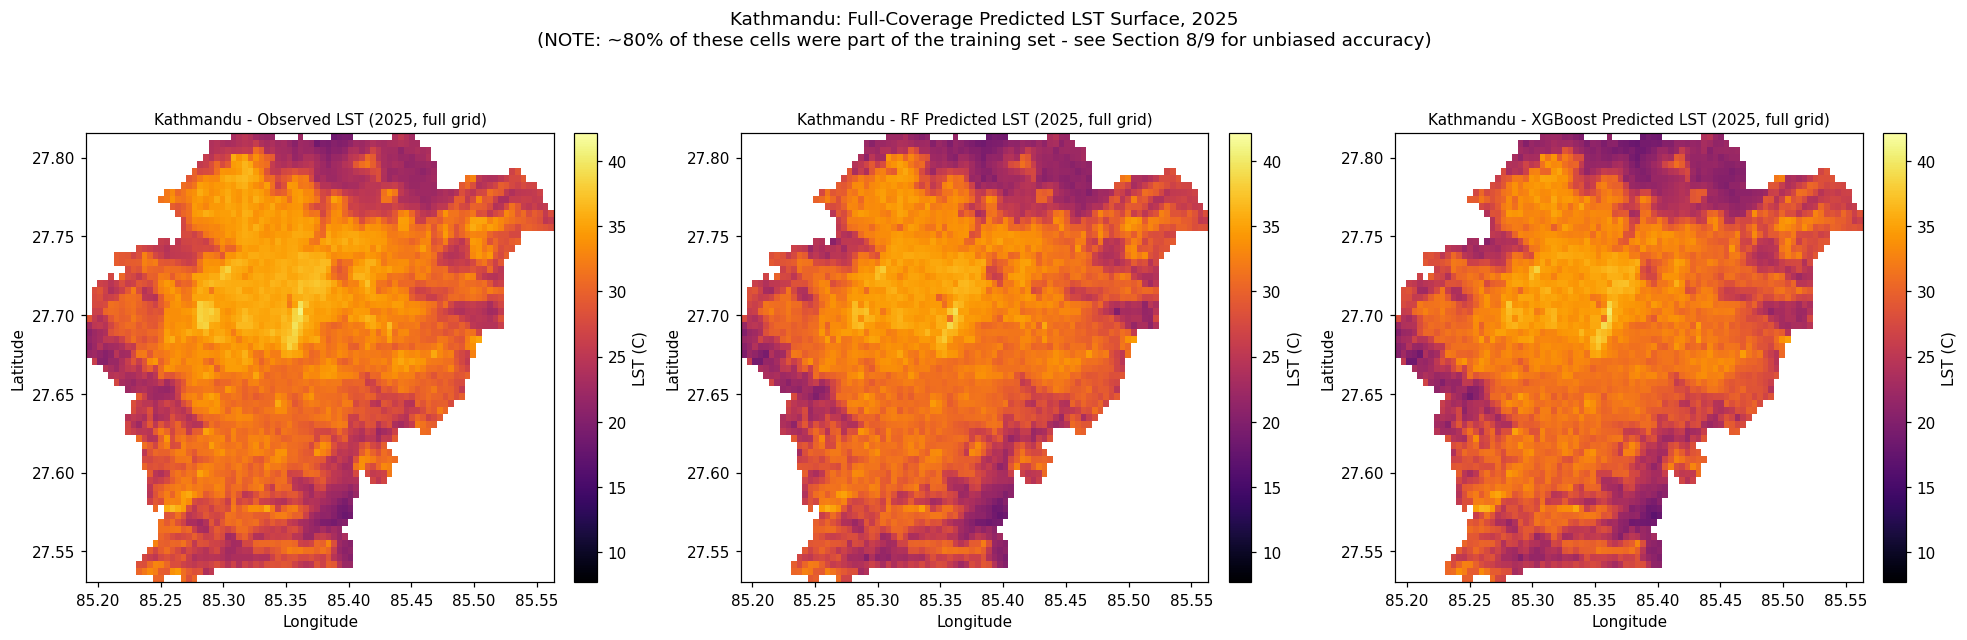

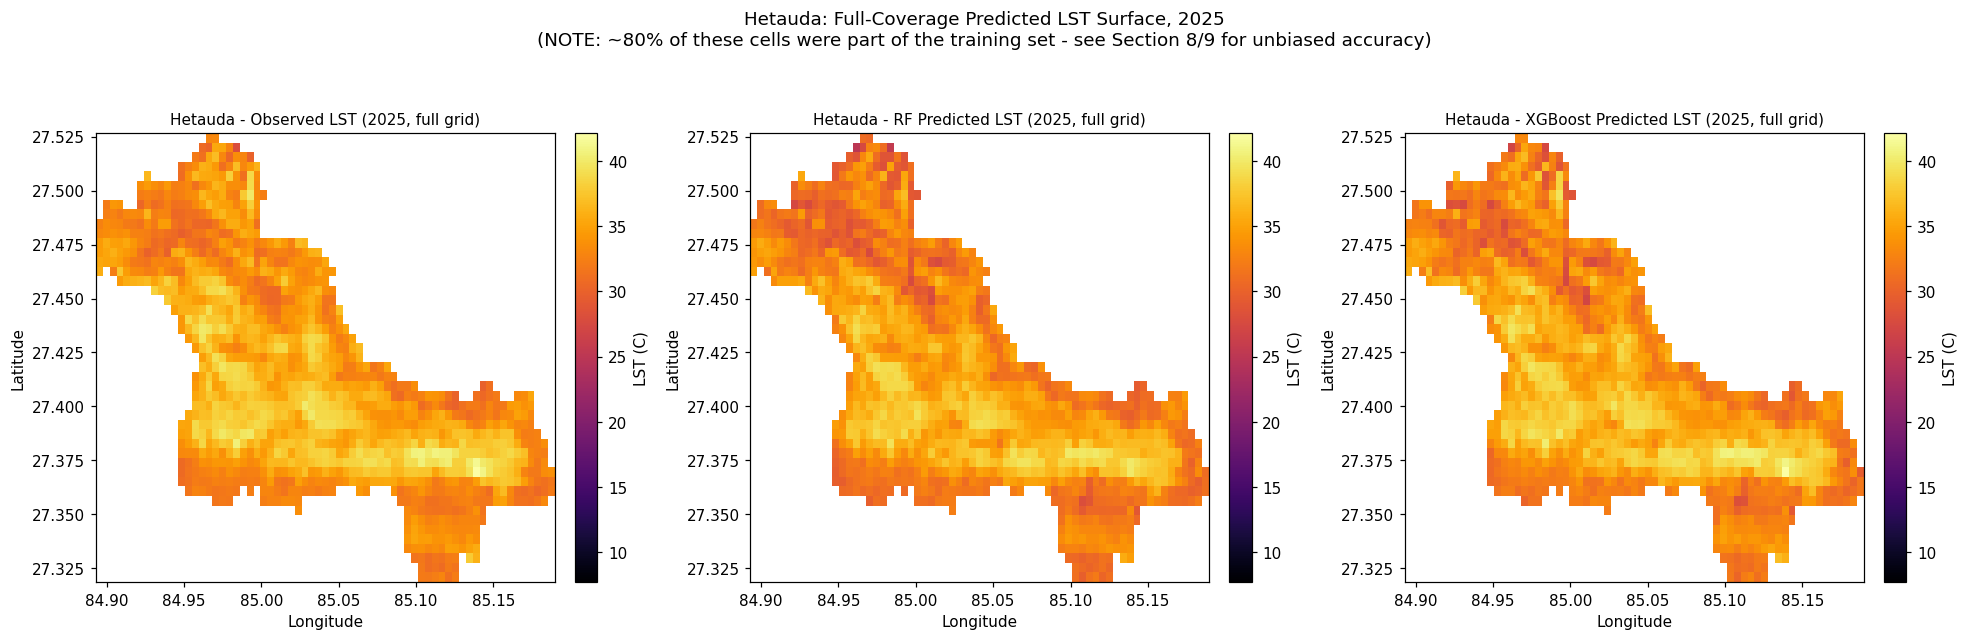

In [19]:
for name in cities_raw:
    d = model_data[name]
    df_full_2025 = d["df_clean"][d["df_clean"].Year == 2025].copy()
    df_full_2025["LST_pred_rf"] = d["rf_model"].predict(df_full_2025[FEATURES])

    n_panels = 3 if (XGB_AVAILABLE and "xgb_model" in d) else 2
    fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 5.5))

    plot_raster(axes[0], name, df_full_2025, "LST", year=2025, cmap="inferno",
                vmin=lst_vmin, vmax=lst_vmax, cbar_label="LST (C)",
                title=f"{name} - Observed LST (2025, full grid)")
    plot_raster(axes[1], name, df_full_2025, "LST_pred_rf", year=2025, cmap="inferno",
                vmin=lst_vmin, vmax=lst_vmax, cbar_label="LST (C)",
                title=f"{name} - RF Predicted LST (2025, full grid)")

    if n_panels == 3:
        df_full_2025["LST_pred_xgb"] = d["xgb_model"].predict(df_full_2025[FEATURES])
        plot_raster(axes[2], name, df_full_2025, "LST_pred_xgb", year=2025, cmap="inferno",
                    vmin=lst_vmin, vmax=lst_vmax, cbar_label="LST (C)",
                    title=f"{name} - XGBoost Predicted LST (2025, full grid)")

    plt.suptitle(f"{name}: Full-Coverage Predicted LST Surface, 2025\n"
                 "(NOTE: ~80% of these cells were part of the training set - see Section 8/9 for unbiased accuracy)",
                 y=1.05, fontsize=12)
    plt.tight_layout()
    plt.savefig(f"fig11_full_surface_{name.lower()}.png", dpi=150, bbox_inches="tight")
    plt.show()


## 12. Spatial Residual Comparison — Random Forest vs. XGBoost

**What it shows:** the two models' test-set residual maps side by side for each city (the same
residual panels from Sections 8 and 9, regrouped for direct comparison rather than repeating them).

**How it's computed:** identical residual definition (`predicted − observed`) and identical color
scale for both models, so the comparison is visually fair.

**What to look for:** this is the spatial complement to the RMSE/MAE table in Section 13 — two models
can have similar aggregate error metrics while making very different *kinds* of mistakes spatially
(e.g. one might be biased in the urban core, the other at the rural fringe). If the two residual maps
look nearly identical, that means the model choice mostly doesn't matter for this dataset beyond the
raw metric; if they look different, that's worth a sentence in the report's model comparison section.


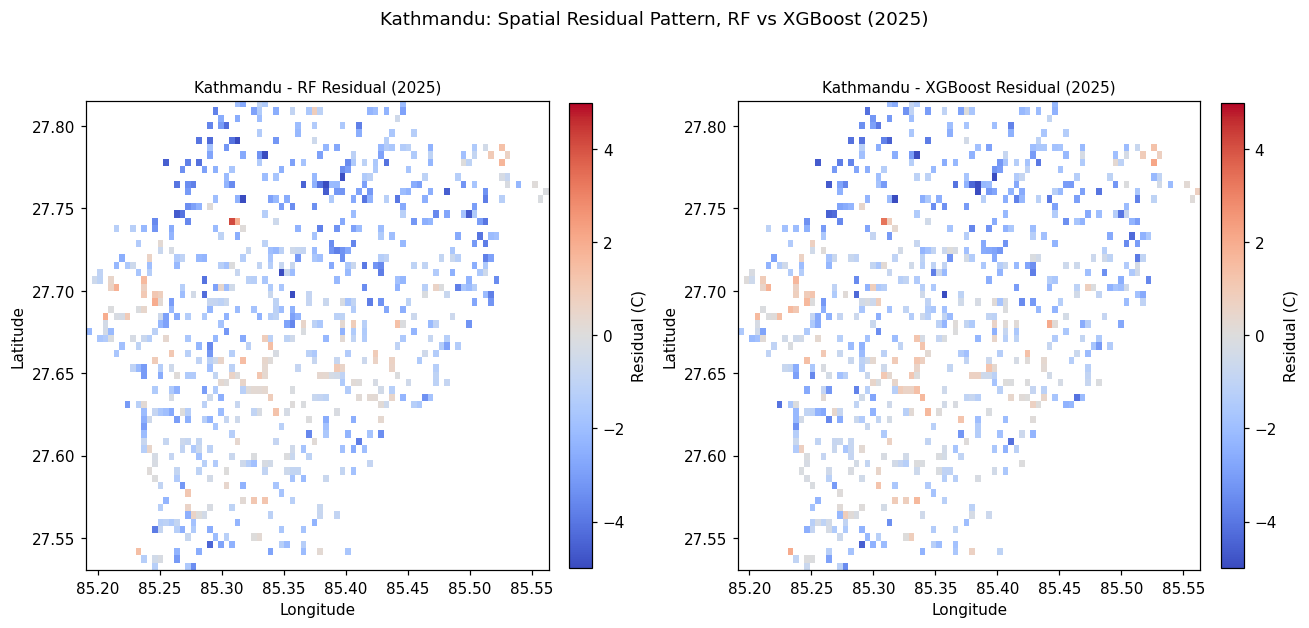

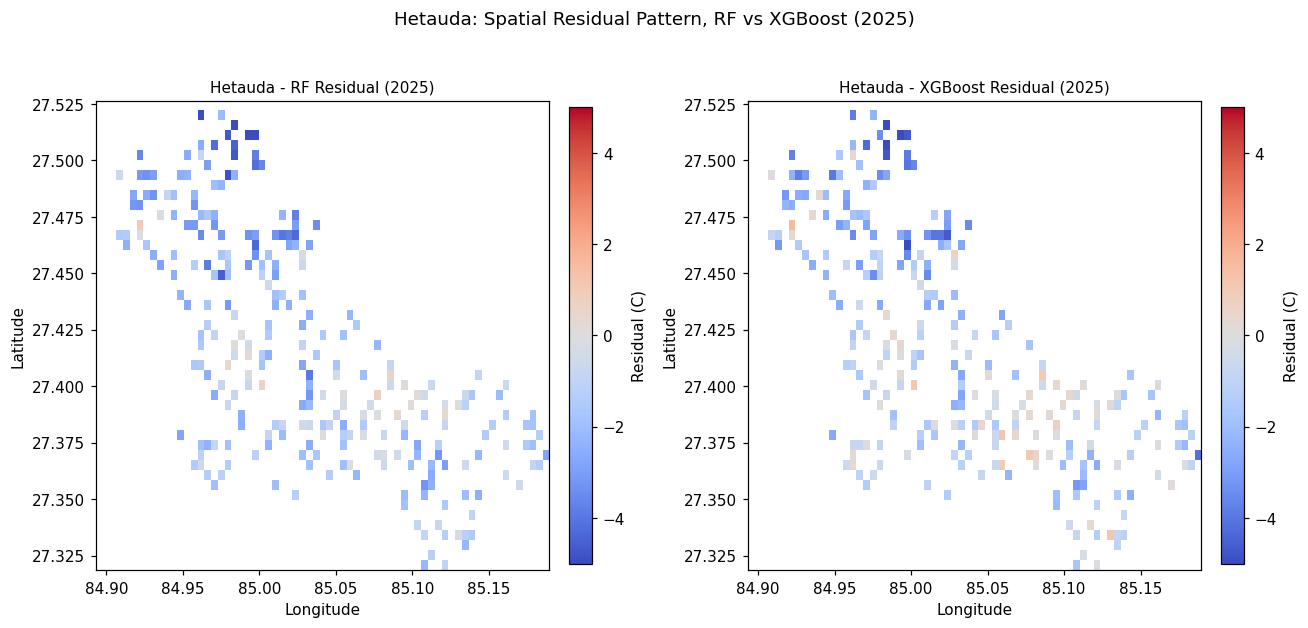

In [20]:
if XGB_AVAILABLE:
    for name in cities_raw:
        df_rf = test_pred_rf[name]
        df_xgb = test_pred_xgb[name]
        map_year_use = df_rf.Year.value_counts().idxmax() if df_rf[df_rf.Year == 2025].shape[0] < 15 else 2025

        fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
        plot_raster(axes[0], name, df_rf, "residual", year=map_year_use, cmap="coolwarm",
                    vmin=-5, vmax=5, cbar_label="Residual (C)",
                    title=f"{name} - RF Residual ({map_year_use})")
        plot_raster(axes[1], name, df_xgb, "residual", year=map_year_use, cmap="coolwarm",
                    vmin=-5, vmax=5, cbar_label="Residual (C)",
                    title=f"{name} - XGBoost Residual ({map_year_use})")
        plt.suptitle(f"{name}: Spatial Residual Pattern, RF vs XGBoost ({map_year_use})", y=1.03)
        plt.tight_layout()
        plt.savefig(f"fig12_residual_comparison_{name.lower()}.png", dpi=150, bbox_inches="tight")
        plt.show()
else:
    print("Skipped (xgboost not installed / Section 2.3 not run).")


## 13. Feature Importance Comparison — RF (Permutation) vs. XGBoost (Gain)

**What it shows:** the top 10 features by importance for each model, side by side per city.

**How it's computed:** Random Forest uses **permutation importance** on the held-out test set (mean
decrease in R² when a feature is randomly shuffled — an out-of-sample, model-agnostic measure).
XGBoost uses **gain-based importance** (average loss reduction attributed to a feature across all its
splits — an in-model measure). These are different statistics computed differently, so the *ranking*
is what's comparable, not the raw magnitudes — the two bars are plotted on separate axes deliberately
rather than forced onto one shared scale, to avoid implying a false equivalence.

**What to look for:** features that rank highly in *both* models (the report's Chapter 3.1 already
found strong overlap — NDBI, Albedo, and the 500 m focal NDBI context were consistently top drivers
for Kathmandu; Albedo and MNDWI dominated for Hetauda) are the safest candidates for the report's
"strongest LST drivers" conclusion, since two structurally different models agreeing is stronger
evidence than either one alone.


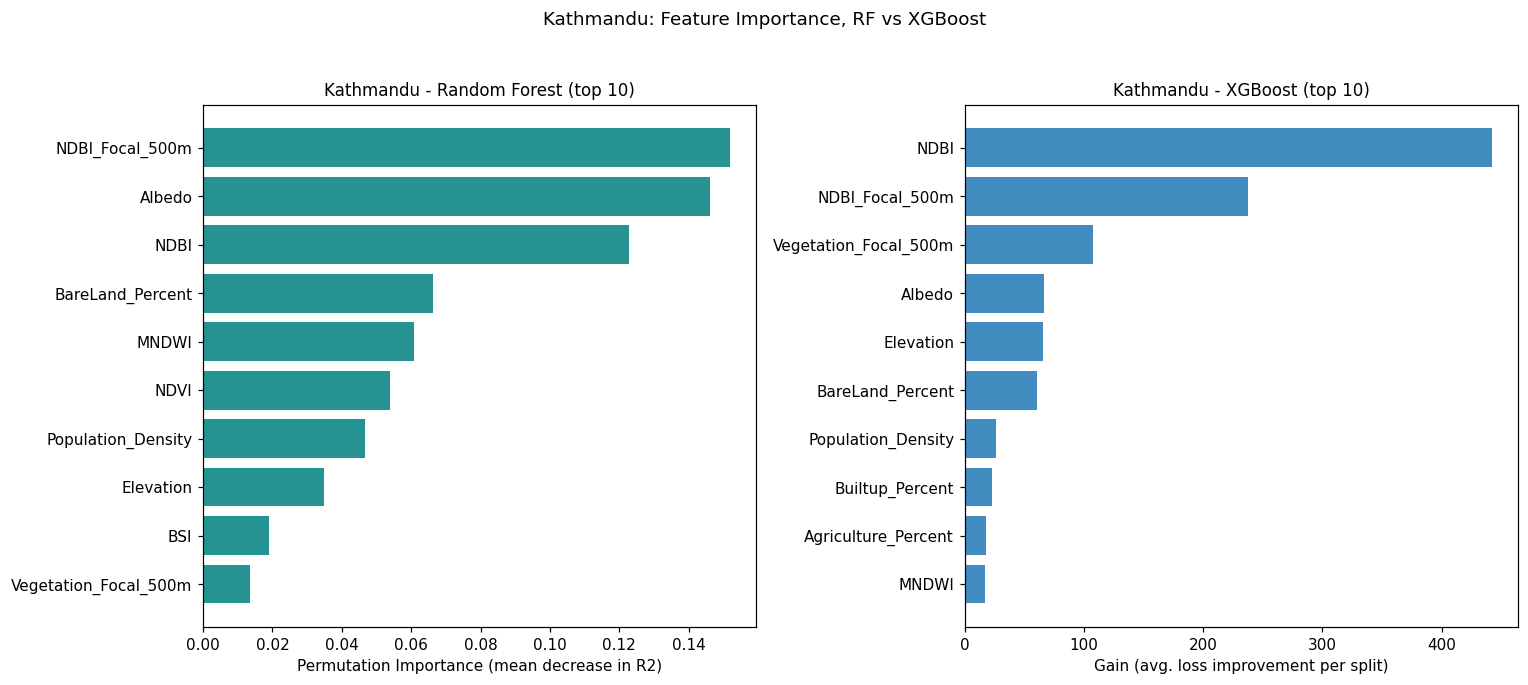

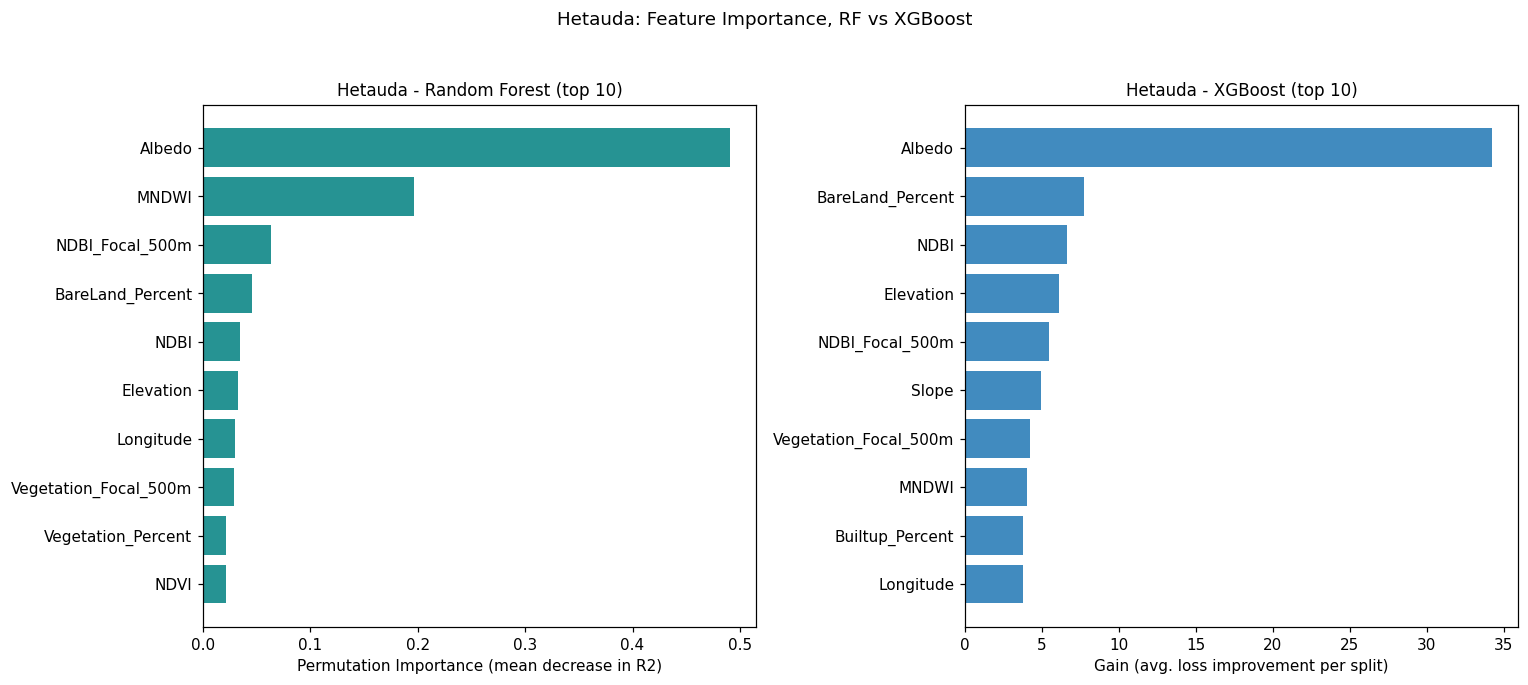

In [21]:
for name in cities_raw:
    d = model_data[name]

    perm_result = permutation_importance(d["rf_model"], d["X_test"], d["y_test"],
                                          n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
    rf_imp = pd.DataFrame({"Feature": d["X_test"].columns, "Importance": perm_result.importances_mean}
                           ).sort_values("Importance", ascending=False).head(10)

    n_panels = 2 if (XGB_AVAILABLE and "xgb_model" in d) else 1
    fig, axes = plt.subplots(1, n_panels, figsize=(7 * n_panels, 6))
    ax0 = axes[0] if n_panels > 1 else axes
    ax0.barh(rf_imp["Feature"][::-1], rf_imp["Importance"][::-1], color="teal", alpha=0.85)
    ax0.set_xlabel("Permutation Importance (mean decrease in R2)")
    ax0.set_title(f"{name} - Random Forest (top 10)")

    if n_panels == 2:
        gain_scores = d["xgb_model"].get_booster().get_score(importance_type="gain")
        xgb_imp = pd.DataFrame({"Feature": list(gain_scores.keys()), "Importance": list(gain_scores.values())}
                                ).sort_values("Importance", ascending=False).head(10)
        axes[1].barh(xgb_imp["Feature"][::-1], xgb_imp["Importance"][::-1], color="#1f77b4", alpha=0.85)
        axes[1].set_xlabel("Gain (avg. loss improvement per split)")
        axes[1].set_title(f"{name} - XGBoost (top 10)")

    plt.suptitle(f"{name}: Feature Importance, RF vs XGBoost", y=1.03)
    plt.tight_layout()
    plt.savefig(f"fig13_feature_importance_{name.lower()}.png", dpi=150, bbox_inches="tight")
    plt.show()


## 14. Model Comparison Summary Table

**What it shows:** RMSE, MAE, and R² for both models on the held-out test set, for both cities —
the same comparison structure as Section 8.6 / Table in your training notebooks, recomputed here
from the reconstructed models for a single consolidated reference table across both cities.


In [22]:
rows = []
for name in cities_raw:
    d = model_data[name]
    rows.append({
        "City": name, "Model": "Random Forest",
        "RMSE (C)": np.sqrt(mean_squared_error(d["y_test"], d["y_pred_rf"])),
        "MAE (C)": mean_absolute_error(d["y_test"], d["y_pred_rf"]),
        "R2": r2_score(d["y_test"], d["y_pred_rf"]),
    })
    if XGB_AVAILABLE and "y_pred_xgb" in d:
        rows.append({
            "City": name, "Model": "XGBoost",
            "RMSE (C)": np.sqrt(mean_squared_error(d["y_test"], d["y_pred_xgb"])),
            "MAE (C)": mean_absolute_error(d["y_test"], d["y_pred_xgb"]),
            "R2": r2_score(d["y_test"], d["y_pred_xgb"]),
        })

comparison_df = pd.DataFrame(rows)
print("FINAL MODEL COMPARISON - RANDOM FOREST vs XGBOOST")
print("=" * 70)
print(comparison_df.to_string(index=False))
comparison_df


FINAL MODEL COMPARISON - RANDOM FOREST vs XGBOOST
     City         Model  RMSE (C)  MAE (C)       R2
Kathmandu Random Forest  1.649987 1.238618 0.837492
Kathmandu       XGBoost  1.584932 1.191038 0.850054
  Hetauda Random Forest  1.610357 1.216610 0.783995
  Hetauda       XGBoost  1.493978 1.135928 0.814088


,City,Model,RMSE (C),MAE (C),R2
0,Kathmandu,Random Forest,1.649987,1.238618,0.837492
1,Kathmandu,XGBoost,1.584932,1.191038,0.850054
2,Hetauda,Random Forest,1.610357,1.216610,0.783995
3,Hetauda,XGBoost,1.493978,1.135928,0.814088


---
## Note on the Remaining Report Elements (ARIMA / MLR Forecasting)

The forecasting stage (Section 3.2 of the report) works on the *aggregated* annual-mean LST series
plotted in Part 1, Section 7 — not on a per-grid-cell basis — so its output is a **line chart**
(historical + ARIMA/MLR projection + confidence interval), not a map. A spatially resolved 2030 LST
map would require extrapolating an 11-point series independently for every one of the ~3,400
(Kathmandu) / ~1,300 (Hetauda) grid cells, which is far less statistically defensible than the single
aggregated series and isn't attempted here — consistent with the limitation already flagged in the
report (Chapter 4).
